# Target: 'Schema' : 5 roots: Training two custom bilstms
# Feature extraction with EfficientNetV2B0

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd

from tensorflow.keras.layers import Input,LSTM,Bidirectional,Dense,BatchNormalization,Activation,MaxPooling2D,Dropout,Reshape,Conv2D,Flatten,GlobalAveragePooling2D,TimeDistributed

from tensorflow.keras.models import Model
from tensorflow.keras.utils import plot_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import F1Score , Precision, Accuracy, BinaryAccuracy, Recall ,AUC
import cv2
from sklearn.metrics import confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input ,EfficientNetV2B0

2025-12-22 00:43:53.198194: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766364233.405518      20 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766364233.462660      20 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


#### Fixing Seed To ensure reproducibility

In [2]:
# # Set seed for reproducibility
# import random
# SEED = 42
# tf.random.set_seed(SEED)
# np.random.seed(SEED)
# random.seed(SEED)
# os.environ['PYTHONHASHSEED'] = str(SEED)
# os.environ['TF_DETERMINISTIC_OPS'] = '1'

# Confuguration


In [3]:
TARGET_TYPE='Schema'
EPOCHS=30
LR=1e-3
LOSS_FUNCTION='binary_crossentropy'
GRAY_SCALING=False

In [4]:
#metrics
f1_score=F1Score()
precision = Precision()
recall =Recall()
binary_accuracy=BinaryAccuracy()
# accuracy = Accuracy()
metrics=[f1_score,precision,recall,'accuracy',binary_accuracy]

class_position_in_path=5

I0000 00:00:1766364248.198850      20 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [5]:
print(tf.__version__)

2.18.0


# Data Preparation

In [6]:
def get_paths(parent_folder):
    import os
    files={}
    for i in os.walk(parent_folder):
        if i[-1]:
            files[i[0]]=[]
            image_name= i[-1][0]
#             files[i[0]].append(image_name)
            for image_name in i[-1]:
                files[i[0]].append(image_name)
    paths=[]
    for parent_path  in files.keys() :
        for image_name in files[parent_path]:
            paths.append(os.path.join(parent_path,image_name))
    return paths

def remove_not_image_files(paths):
    for p in paths:
        if not p.endswith('.png') and  not p.endswith('.jpg') and not p.endswith('.jpeg') and not p.endswith('.bmp'):
            print("path will be removed:"+p)
            paths.remove(p)
        else:
            try:
                plt.imread(p)
            except:
                paths.remove(p)
                print("cannot read path, will be removed:"+p)

    return paths

In [7]:
def preprocess_paths(parent_path):
    paths=get_paths(parent_path)
    n_paths_before=len(paths)
    i=0
    while(i<3):
        paths=remove_not_image_files(paths)
        i=i+1
    n_paths_after=len(paths)
    print(f"{n_paths_before - n_paths_after} paths have been removed from {n_paths_before}")
    return paths

In [8]:
parent_folder ='/kaggle/input/5-arabic-roots'
paths=preprocess_paths(parent_folder)

path will be removed:/kaggle/input/5-arabic-roots/corpus1/Corpus_Apprentissage_CNN_5_racines.xml
cannot read path, will be removed:/kaggle/input/5-arabic-roots/corpus1/0/2/6_pr�sent/11_ghaeb/2_hom/Image_16_Arabic Transparent_1.png
cannot read path, will be removed:/kaggle/input/5-arabic-roots/corpus1/0/2/6_pr�sent/11_ghaeb/2_hom/Image_24_Arabic Transparent_1.png
cannot read path, will be removed:/kaggle/input/5-arabic-roots/corpus1/0/2/6_pr�sent/11_ghaeb/2_hom/Image_14_Arabic Transparent_1.png
cannot read path, will be removed:/kaggle/input/5-arabic-roots/corpus1/0/2/6_pr�sent/11_ghaeb/3_honna/Image_16_Arabic Transparent_1.png
cannot read path, will be removed:/kaggle/input/5-arabic-roots/corpus1/0/2/6_pr�sent/11_ghaeb/3_honna/Image_24_Arabic Transparent_1.png
cannot read path, will be removed:/kaggle/input/5-arabic-roots/corpus1/0/0/6_pr�sent/11_ghaeb/2_hom/Image_24_Arabic Transparent_4.png
cannot read path, will be removed:/kaggle/input/5-arabic-roots/corpus1/0/0/6_pr�sent/11_ghaeb/2

In [9]:
def get_ref_from_path(path,folder_position):
    if  path.startswith('/'):
        folder_position= folder_position+1
    return path.split('/')[folder_position]

In [10]:
def get_refs_from_paths(paths,folder_position):
    labels=[]
    for path in paths:
        labels.append(get_ref_from_path(path,folder_position))
    return labels

In [11]:
paths[0]

'/kaggle/input/5-arabic-roots/corpus1/0/2/6_pr�sent/10_moukhatab/2_antouma/Image_24_Arabic Transparent_15472.png'

## Choosing the target

In [12]:
refs=get_refs_from_paths(paths,class_position_in_path)

## Prepare dataframe:

In [13]:
d = {'path': paths, 'ref':refs}
df =pd.DataFrame.from_dict(d)

In [14]:
df

,path,ref
0,/kaggle/input/5-arabic-roots/corpus1/0/2/6_pr�...,2
1,/kaggle/input/5-arabic-roots/corpus1/0/2/6_pr�...,2
2,/kaggle/input/5-arabic-roots/corpus1/0/2/6_pr�...,2
3,/kaggle/input/5-arabic-roots/corpus1/0/2/6_pr�...,2
4,/kaggle/input/5-arabic-roots/corpus1/0/2/6_pr�...,2
...,...,...
1011,/kaggle/input/5-arabic-roots/corpus1/76/3/5_pa...,3
1012,/kaggle/input/5-arabic-roots/corpus1/76/3/5_pa...,3
1013,/kaggle/input/5-arabic-roots/corpus1/76/3/5_pa...,3
1014,/kaggle/input/5-arabic-roots/corpus1/76/3/5_pa...,3


In [15]:
# first_Schema = [
#     '0_ana'
# ]
# second_person = [
#     '2_antouma',
#     '3_antom',
#     '0_antouma',
#     '1_anti',
#     '0_anta',
#     '4_antonna',
#     '3_antouma',
#     '1_anta',
#     '2_anti',
#     '2_antonna',
#     '0_anti',
#     '4_antom',
#     '1_antom',
#     '5_antonna'
# ]
# third_person = [
#     '0_houa',
#     '3_houma_f',
#     '1_hya',
#     '4_hom',
#     '2_hom',
#     '1_houma_m',
#     '3_honna',
#     '3_hom',
#     '4_honna',
#     '5_honna',
#     '2_houma_m'  # moved here (was misclassified as 2nd person)
# ]
# noun=[
#     '3_masculin',
#     '4_feminin'
# ]

In [16]:
# df['ref0'] = df['ref']
# df['ref'] = df['ref0'].map(lambda x: 'first_person' if x in first_person 
#                            else 'second_person' if x in second_person 
#                            else 'third_person' if x in third_person 
#                            else 'noun' if x in noun
#                            else 'autre'
#                           )

In [17]:
# SELECTED_CLASS_NAMES=['first_person','second_person','third_person','noun']

In [18]:
# df = df[df['ref'].isin(SELECTED_CLASS_NAMES)]

In [19]:
df['ref'].value_counts()

ref
2     310
0     306
3     163
15    103
14     40
1      30
5      28
17     16
19     12
16      8
Name: count, dtype: int64

In [20]:
df['ref'].value_counts().index

Index(['2', '0', '3', '15', '14', '1', '5', '17', '19', '16'], dtype='object', name='ref')

## Select necessary words. 

In [21]:
def ref_to_label(refs:list):
    classes=sorted(list(set(refs)))
    labels = []
    labels_refs_map={}
    for ref in refs:
        labels_refs_map[classes.index(ref)]=ref
        labels.append(str(classes.index(ref)))
    return labels ,labels_refs_map
def prepare_dataframe(paths,refs):
    """
    Role:
        - Prepare dataframe  that conatains the paths of the images and its corresponding labels.
    Inputs:
        - paths : list()
        - labels: list()
    Outputs:
        df : pd.Dataframe()
    """
    import pandas as pd
    labels,REFS_LABELS_MAP = ref_to_label(refs)
    d = {'path': paths, 'ref':refs,'label':labels}
    df =pd.DataFrame.from_dict(d)
    return df,REFS_LABELS_MAP
# test:
df,REFS_LABELS_MAP =prepare_dataframe(df.path.values,df.ref.values)
df,REFS_LABELS_MAP

(                                                   path ref label
 0     /kaggle/input/5-arabic-roots/corpus1/0/2/6_pr�...   2     7
 1     /kaggle/input/5-arabic-roots/corpus1/0/2/6_pr�...   2     7
 2     /kaggle/input/5-arabic-roots/corpus1/0/2/6_pr�...   2     7
 3     /kaggle/input/5-arabic-roots/corpus1/0/2/6_pr�...   2     7
 4     /kaggle/input/5-arabic-roots/corpus1/0/2/6_pr�...   2     7
 ...                                                 ...  ..   ...
 1011  /kaggle/input/5-arabic-roots/corpus1/76/3/5_pa...   3     8
 1012  /kaggle/input/5-arabic-roots/corpus1/76/3/5_pa...   3     8
 1013  /kaggle/input/5-arabic-roots/corpus1/76/3/5_pa...   3     8
 1014  /kaggle/input/5-arabic-roots/corpus1/76/3/5_pa...   3     8
 1015  /kaggle/input/5-arabic-roots/corpus1/76/3/5_pa...   3     8
 
 [1016 rows x 3 columns],
 {7: '2',
  0: '0',
  3: '15',
  5: '17',
  4: '16',
  8: '3',
  2: '14',
  6: '19',
  9: '5',
  1: '1'})

## Exploaratory data analysis

### Class Distribution 

In [22]:
#plot function
def show_plot(path):
    import matplotlib.pyplot as plt
    img = plt.imread(path)
    plt.imshow(img)

In [23]:
#plot function
def plot_distribution(classe_names,distribution,subset_name):
    plt.style.use('seaborn-dark-palette')
    classes=classe_names
    values =distribution
    plt.figure(figsize = (20, 5))
    plt.bar(classes, values,width = 0.7)

    plt.xlabel("Schema id")
    plt.ylabel("Nb. words")
    plt.title(f"Repartition of {sum(values)} words in the {subset_name} data")
    def addlabels(x,y):
        for i in range(len(x)):
            plt.text(i, y[i], y[i], ha = 'center',color='black',style='italic',size="x-large")
    addlabels(classes,values)

In [24]:
series = df['ref'].value_counts()
values= series.values
keys = series.index

In [25]:
keys, len(keys)

(Index(['2', '0', '3', '15', '14', '1', '5', '17', '19', '16'], dtype='object', name='ref'),
 10)

/tmp/ipykernel_20/894278990.py:3: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-dark-palette')


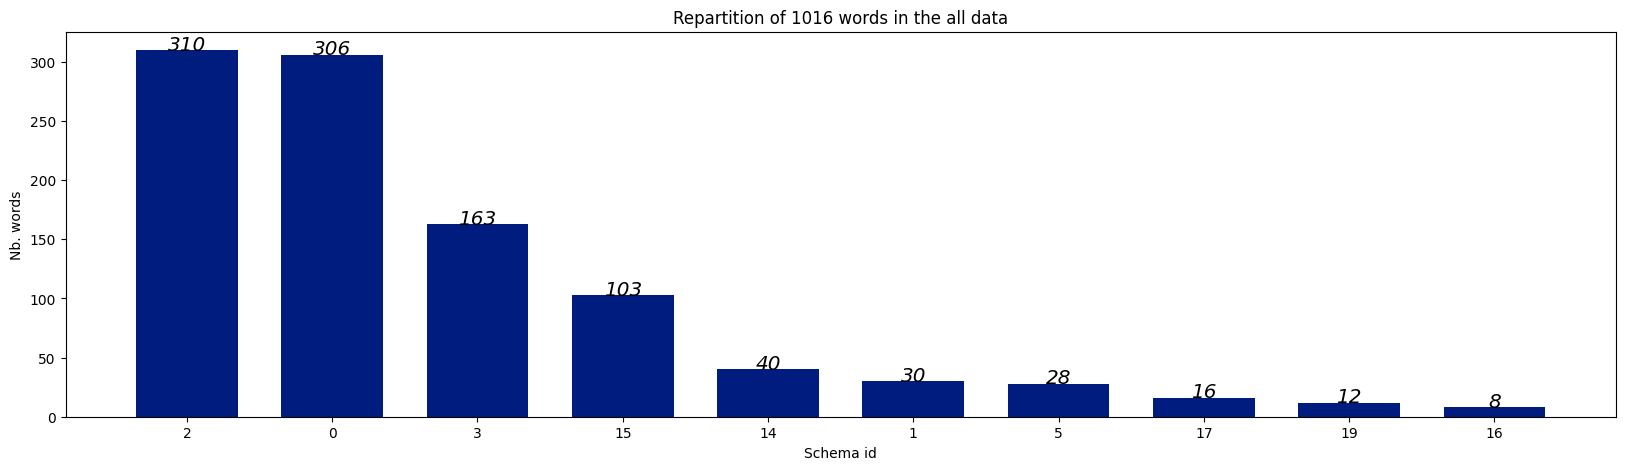

In [26]:
plot_distribution(keys,values,'all')

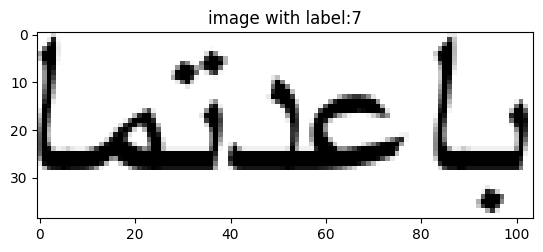

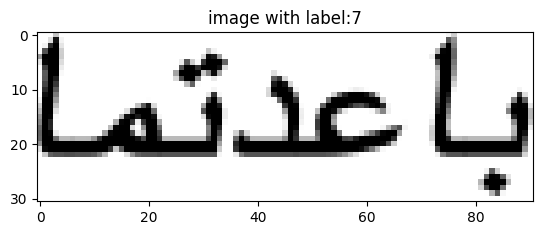

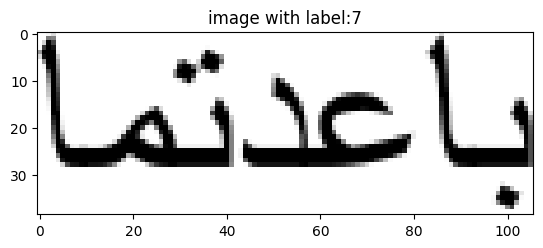

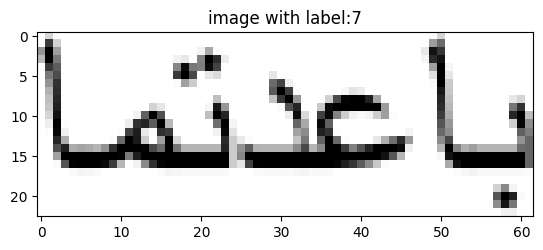

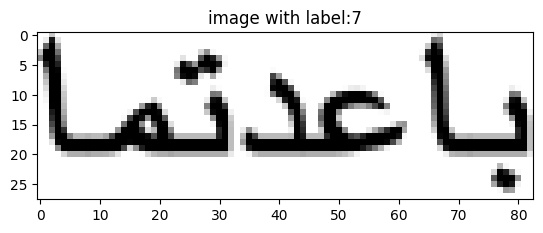

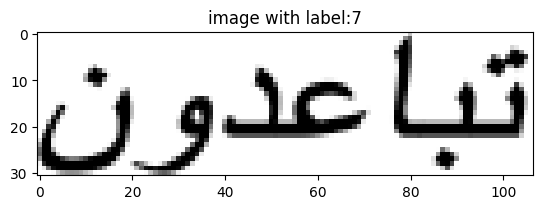

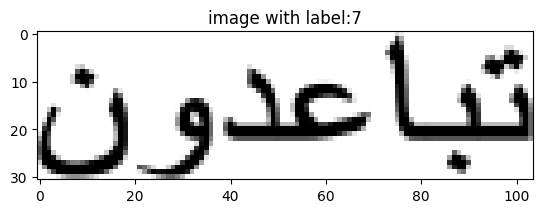

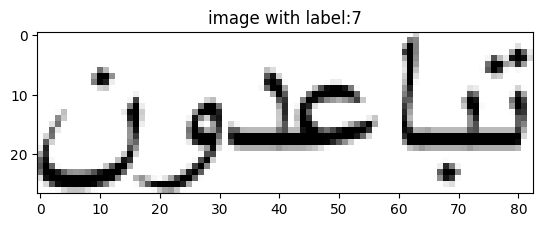

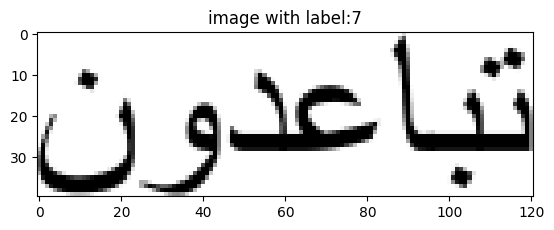

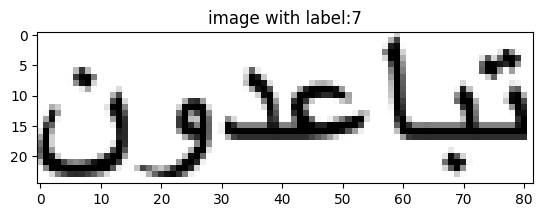

In [27]:
for i,path in enumerate(df['path'][:10]):
    im = cv2.imread(path)
    plt.figure()
    plt.title("image with label:"+df['label'][i])
    plt.imshow(im)

## split data :train ,test ,val

In [28]:
from sklearn.model_selection import train_test_split
train_df,test_df = train_test_split(df,test_size=0.2,shuffle=True,stratify=df['label'])
# val_df,test_df = train_test_split(test_df,test_size=0.5,shuffle=True,stratify=test_df['label'])

In [29]:
train_series = train_df['ref'].value_counts()
train_values = train_series.values
train_keys = train_series.index

/tmp/ipykernel_20/894278990.py:3: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-dark-palette')


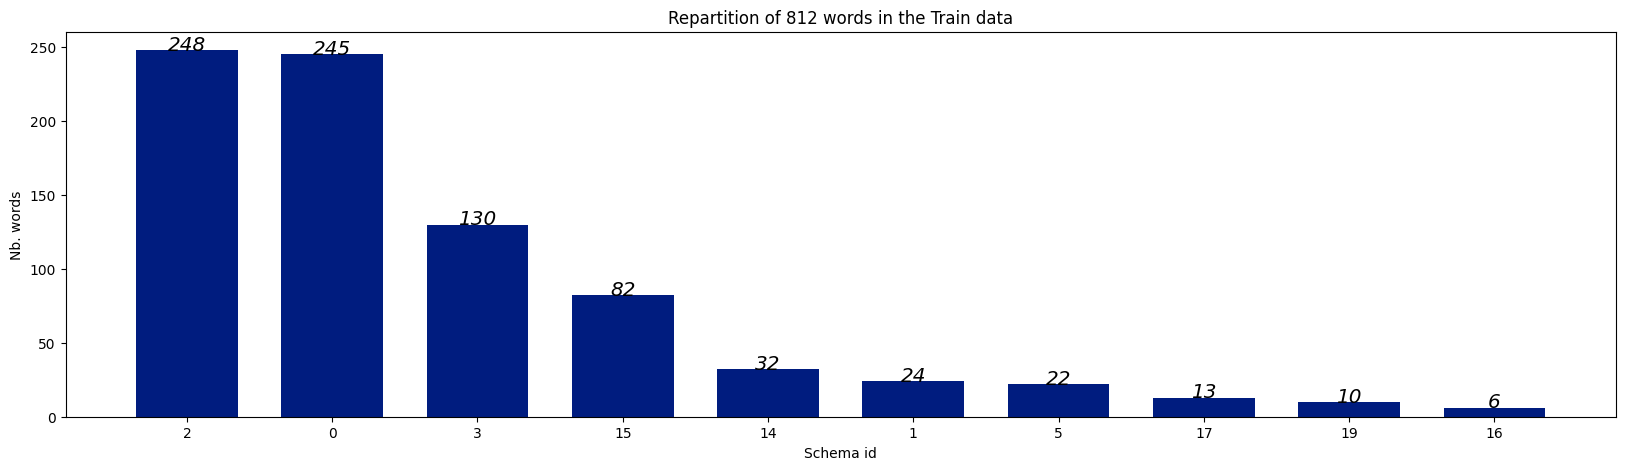

In [30]:
plot_distribution(train_keys,train_values,'Train')

## Test data

In [31]:
test_series = test_df['ref'].value_counts()
test_values = test_series.values
test_keys = test_series.index

/tmp/ipykernel_20/894278990.py:3: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-dark-palette')


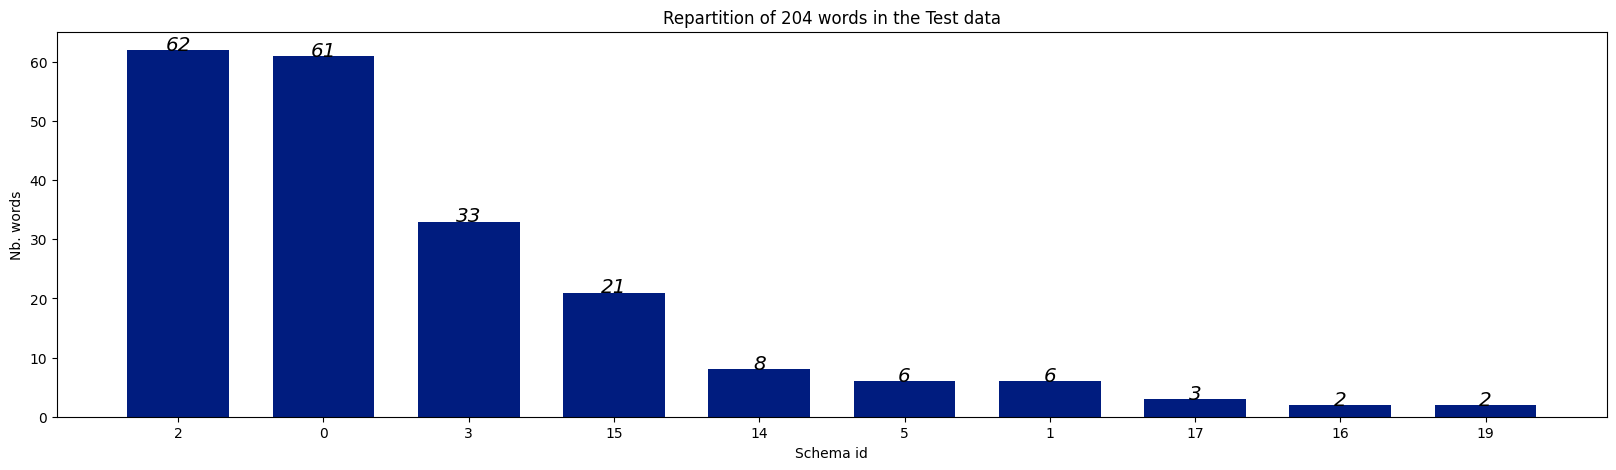

In [32]:
plot_distribution(test_keys,test_values,'Test')

## Load images and prepare lables

In [33]:
def reshape_image(img):
    import cv2
    import numpy as np
    (h, w,d) = img.shape
    
    final_img = np.ones([128, 256,3])*255 # blank white image
    
    # crop
    if w > 256:
        img = img[:, :256]
        
    if h > 128:
        img = img[:128, :]
        
    final_img[:h,:w,:d] = img
    # return cv2.rotate(final_img, cv2.ROTATE_90_CLOCKWISE)
    return final_img

def prepare_images(paths):
    import cv2
    import numpy as np
    images=[]
    bad_images_indexs=[]
    for i,path in enumerate(paths):
        try:
            if(GRAY_SCALING):
                im = cv2.imread(path,cv2.IMREAD_GRAYSCALE)
            else:
                im = cv2.imread(path)
                
            im = reshape_image(im)
            im = im/255.
            images.append(im)
        except:
            bad_images_indexs.append(i)
            print(f"Error loading image {path}")
    print(f"found {len(images)} images with {im.shape} shapes")
    return images , bad_images_indexs

In [34]:
def prepare_xy(paths,labels):
    x,bad_images_indexs = prepare_images(paths)
    cleaned_labels=[]
    for i,label in enumerate(labels):
        if i not in bad_images_indexs:
            cleaned_labels.append(label)
    y = tf.keras.utils.to_categorical(cleaned_labels)
    return x ,y

In [35]:
len(paths)

1016

### Image generator

In [36]:
generator = ImageDataGenerator(preprocessing_function=reshape_image)

In [37]:
ALL_CLASSES=df['label'].value_counts().index
ALL_CLASSES

Index(['7', '0', '8', '3', '2', '1', '9', '5', '6', '4'], dtype='object', name='label')

## Train data

In [38]:
train_df.shape,len(train_df['label'])

((812, 3), 812)

In [39]:
train_df['label'].value_counts().sum()

812

In [40]:
train_df

,path,ref,label
772,/kaggle/input/5-arabic-roots/corpus1/74/3/5_pa...,3,8
384,/kaggle/input/5-arabic-roots/corpus1/16/19/nom...,19,6
935,/kaggle/input/5-arabic-roots/corpus1/76/15/nom...,15,3
83,/kaggle/input/5-arabic-roots/corpus1/0/0/6_pr�...,0,0
483,/kaggle/input/5-arabic-roots/corpus1/16/0/5_pa...,0,0
...,...,...,...
441,/kaggle/input/5-arabic-roots/corpus1/16/5/5_pa...,5,9
229,/kaggle/input/5-arabic-roots/corpus1/34/2/nom/...,2,7
693,/kaggle/input/5-arabic-roots/corpus1/74/0/5_pa...,0,0
731,/kaggle/input/5-arabic-roots/corpus1/74/3/6_pr...,3,8


In [41]:
train_gen=generator.flow_from_dataframe(
    dataframe=train_df,
    directory='/',
    x_col='path',
    y_col='label',
    class_mode='categorical',
    color_mode='rgb',
    batch_size=16,
    target_size=(128,256),
    shuffle=False
)

Found 812 validated image filenames belonging to 10 classes.


In [42]:
images, labels=next(train_gen)

In [43]:
labels

array([[0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

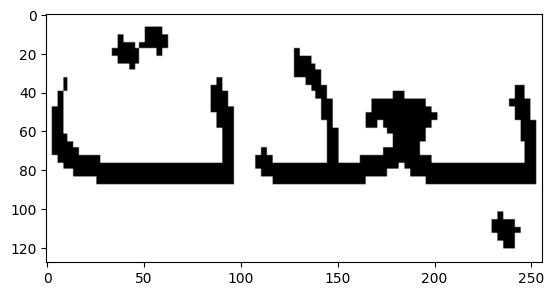

In [44]:
plt.imshow(images[15])

# Test DATA

In [45]:
test_gen=generator.flow_from_dataframe(
    dataframe=test_df,
    directory='/',
    x_col='path',
    y_col='label',
    class_mode='categorical',
    color_mode='rgb',
    batch_size=16,
    target_size=(128,256),
    shuffle=True
)

Found 204 validated image filenames belonging to 10 classes.


# Training

## Backbone model

In [46]:
backbone=EfficientNetV2B0(weights='imagenet',include_top=False,input_shape=(128, 256, 3))

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## 1.BiLSTM WITH Embedded CNN:

In [47]:
@tf.keras.utils.register_keras_serializable(package="Custom")
class MyLSTM(tf.keras.layers.Layer):
    def __init__(self,
                 units,
                 return_sequences=False,
                 kernel_size=3,
                 nb_channels=1,
                 filters=None,
                 cnn_strides=2,
                 cnn_padding='SAME',
                 lambda_param=0.1,
                 **kwargs):
        super(MyLSTM, self).__init__(**kwargs)
        
        self.units = units
        self.return_sequences = return_sequences
        self.kernel_size = kernel_size
        self.nb_channels = nb_channels
        self.filters = filters if filters is not None else units
        self.cnn_strides = cnn_strides
        self.cnn_padding = cnn_padding
        self.lambda_param = lambda_param
        
    def build(self,input_shape):
        nb_features=input_shape[-1]
        self.input_dim = input_shape[-1]
        self.wi= self.add_weight(shape=(self.units,self.units),initializer="glorot_uniform",name="wi")
        self.ui= self.add_weight(shape=(nb_features,self.units),initializer="orthogonal", name="ui")
        self.bi= self.add_weight(shape=(self.units,) , initializer="zeros",name="bi")

        self.wf= self.add_weight(shape=(self.units,self.units),initializer="glorot_uniform",name="wf")
        self.uf= self.add_weight(shape=(nb_features,self.units),initializer="orthogonal", name="uf")
        self.bf= self.add_weight(shape=(self.units,) , initializer="zeros",name="bf")

        self.wc= self.add_weight(shape=(self.units,self.units),initializer="glorot_uniform",name="wc")
        self.uc= self.add_weight(shape=(nb_features,self.units),initializer="orthogonal", name="uc")
        self.bc= self.add_weight(shape=(self.units,) , initializer="zeros",name="bc")

        self.wo= self.add_weight(shape=(self.units,self.units),initializer="glorot_uniform",name="wo")
        self.uo= self.add_weight(shape=(nb_features,self.units),initializer="orthogonal", name="uo")
        self.bo= self.add_weight(shape=(self.units,) , initializer="zeros",name="bo")    

        if(len(input_shape)==4):
            self.nb_channels=input_dim[-1]
            
        self.wcnn = self.add_weight(shape=(self.kernel_size,self.kernel_size,self.nb_channels,self.filters),initializer="glorot_uniform",name="lstm_kernel")
        self.bcnn = self.add_weight(shape=(self.filters,),initializer="zeros",name="ltsm_kernel_bias")


    def convolutional_operation(self,inputs):
        # Perform the convolution operation
        output = tf.nn.conv2d(
            inputs,
            filters=self.wcnn,
            strides=self.cnn_strides,
            padding=self.cnn_padding  # TensorFlow expects 'VALID' or 'SAME'
        )
        
        # Add the bias
        output = tf.nn.bias_add(output, self.bcnn)
        return tf.tanh(output) 
    
    def call(self,inputs):
        timesteps = inputs.shape[1]
        batch_size = tf.shape(inputs)[0]
        h = tf.zeros((batch_size, self.units))
        c = tf.zeros((batch_size, self.units))
        # z = tf.zeros((self.units,self.units))
        # zu = tf.zeros((self.input_dim,self.units))
        state=[h,c]
        outputs=[]
        conv_input = tf.reshape(inputs,[tf.shape(inputs)[0],tf.shape(inputs)[1],tf.shape(inputs)[2],1])        
        space_features = self.convolutional_operation(conv_input)
        space_features = tf.reduce_sum(space_features,axis=2) # (batch_size,timesteps,feature_size,nb_filters) =>(batch_size,timesteps,nb_filters)
        space_features =tf.reduce_sum(space_features,axis=1) # (batch_size,timesteps,nb_filters) => (batch_size,nb_filters)
        for t in range(timesteps):
            xt = inputs[:,t,:]
            ht_1=  tf.reshape(state[0], [-1, self.units])
            ct_1= state[1]
            i = tf.sigmoid(tf.matmul(ht_1,self.wi) +tf.matmul(xt,self.ui)+self.bi)
            f = tf.sigmoid(tf.matmul(ht_1,self.wf) + tf.matmul(xt,self.uf)+ self.bf)
            c_hat = tf.tanh(tf.matmul(ht_1,self.wc)+ tf.matmul(xt,self.uc) + self.bc)
            o = tf.sigmoid(tf.matmul(ht_1,self.wo)+tf.matmul(xt,self.uo) + self.bo)

            # ct = ct_1*f + i*c_hat + tf.tanh(space_features)
            ct = ct_1*f + i*c_hat + self.lambda_param*tf.tanh(space_features)
            
            ht = o*tf.tanh(ct)
            if self.return_sequences:
                outputs.append(ht)
            state=[ht,ct]

        if self.return_sequences:
            return tf.stack(outputs,axis=1)

        else: 
            return state[0]


    def get_config(self):
        config = super().get_config()
        config.update({
            "return_sequences": self.return_sequences,
            "units": self.units,
            "kernel_size": self.kernel_size,
            "nb_channels": self.nb_channels,
            "filters": self.filters,
            "cnn_strides": self.cnn_strides,
            "cnn_padding" : self.cnn_padding,
            "lambda_param" : self.lambda_param
        })
        return config   
        

In [48]:
import tensorflow as tf

@tf.keras.utils.register_keras_serializable(package="Custom1")
class MyBidirectional(tf.keras.layers.Layer):
    def __init__(self, layer=None, merge_mode="concat", **kwargs):
        super(MyBidirectional, self).__init__(**kwargs)

        # The inner layer is optional so it can be reconstructed safely
        if layer is not None:
            self.forward_layer = layer
            self.backward_layer = tf.keras.layers.deserialize(
                tf.keras.layers.serialize(layer)
            )
        else:
            self.forward_layer = None
            self.backward_layer = None

        self.merge_mode = merge_mode

    def build(self, input_shape):
        # If layers exist, ensure they're built
        if self.forward_layer is not None and not self.forward_layer.built:
            self.forward_layer.build(input_shape)
        if self.backward_layer is not None and not self.backward_layer.built:
            self.backward_layer.build(input_shape)
        super(MyBidirectional, self).build(input_shape)

    def call(self, inputs):
        forward_output = self.forward_layer(inputs)

        reversed_inputs = tf.reverse(inputs, axis=[1])
        backward_output = self.backward_layer(reversed_inputs)
        backward_output = tf.reverse(backward_output, axis=[1])

        if self.merge_mode == "concat":
            return tf.concat([forward_output, backward_output], axis=-1)
        elif self.merge_mode == "sum":
            return forward_output + backward_output
        else:
            raise ValueError(f"Unsupported merge_mode: {self.merge_mode}")

    def get_config(self):
        config = super(MyBidirectional, self).get_config()
        config.update({
            "layer": tf.keras.layers.serialize(self.forward_layer)
                if self.forward_layer is not None else None,
            "merge_mode": self.merge_mode,
        })
        return config

    @classmethod
    def from_config(cls, config):
        layer_config = config.pop("layer", None)
        layer = (
            tf.keras.layers.deserialize(layer_config)
            if layer_config is not None
            else None
        )
        return cls(layer=layer, **config)


In [49]:
# CLASS_NAMES=np.unique(train_gen.labels)
CLASS_NAMES = np.unique(train_gen.labels) 
NB_CLASSES=len(CLASS_NAMES) # also len(train_gen.class_indices)
CLASS_NAMES,NB_CLASSES

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), 10)

In [50]:
input_data = backbone.input 
inner = backbone.output
##  Bidirectional lstm from scratch : 
inner = Reshape(target_shape=(32,1280), name='reshape')(inner)
inner = MyBidirectional(MyLSTM(256, return_sequences=True), name = 'c_bilstm1_cnn')(inner)
inner = MyBidirectional(MyLSTM(256, return_sequences=False), name = 'c_bilstm2_cnn')(inner)

inner = Dense(1000, activation='relu', kernel_initializer='he_normal', name='dense2')(inner)
## OUTPUT
inner = Dense(NB_CLASSES, kernel_initializer='he_normal',name='dense3')(inner)
y_pred = Activation('sigmoid', name='sigmoid')(inner)
model = Model(inputs=input_data, outputs=y_pred)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 128, 256, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling (Rescaling)     │ (None, 128, 256, 3)    │              0 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ normalization             │ (None, 128, 256, 3)    │              0 │ rescaling[0][0]        │
│ (Normalization)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv (Conv2D)        │ (None, 64, 128, 32)    │            864 │ normalization[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_bn                   │ (None, 64, 128, 32)    │            128 │ stem_conv[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_activation           │ (None, 64, 128, 32)    │              0 │ stem_bn[0][0]          │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_project_conv      │ (None, 64, 128, 16)    │          4,608 │ stem_activation[0][0]  │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_project_bn        │ (None, 64, 128, 16)    │             64 │ block1a_project_conv[… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_project_activati… │ (None, 64, 128, 16)    │              0 │ block1a_project_bn[0]… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2a_expand_conv       │ (None, 32, 64, 64)     │          9,216 │ block1a_project_activ… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2a_expand_bn         │ (None, 32, 64, 64)     │            256 │ block2a_expand_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2a_expand_activation │ (None, 32, 64, 64)     │              0 │ block2a_expand_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2a_project_conv      │ (None, 32, 64, 32)     │          2,048 │ block2a_expand_activa… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2a_project_bn        │ (None, 32, 64, 32)     │            128 │ block2a_project_conv[… │
│ (BatchNormalization)      │                        │                │                        │
├──────────────────────

 Total params: 11,175,250 (42.63 MB)

 Trainable params: 11,114,642 (42.40 MB)

 Non-trainable params: 60,608 (236.75 KB)

In [51]:
model.compile(optimizer=Adam(LR),loss=LOSS_FUNCTION,metrics=metrics)

In [52]:
BATCH_SIZE=8
STEPS=int(train_gen.n / BATCH_SIZE) + 1
history=model.fit(train_gen,
                   validation_data=test_gen,
                   steps_per_epoch=STEPS,
                   epochs=EPOCHS,
                   verbose=2)

Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1766364387.060188      60 service.cc:148] XLA service 0x4a485b00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1766364387.061027      60 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1766364400.473124      60 cuda_dnn.cc:529] Loaded cuDNN version 90300
E0000 00:00:1766364417.522491      60 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1766364417.707767      60 gpu_timer.cc:82] 

102/102 - 346s - 3s/step - accuracy: 0.5603 - binary_accuracy: 0.9188 - f1_score: 0.2491 - loss: 0.2039 - precision: 0.6509 - recall: 0.4064 - val_accuracy: 0.8039 - val_binary_accuracy: 0.9632 - val_f1_score: 0.4349 - val_loss: 0.0974 - val_precision: 0.8772 - val_recall: 0.7353
Epoch 2/30
102/102 - 4s - 41ms/step - accuracy: 0.8300 - binary_accuracy: 0.9663 - f1_score: 0.5787 - loss: 0.0874 - precision: 0.8606 - recall: 0.7906 - val_accuracy: 0.8971 - val_binary_accuracy: 0.9794 - val_f1_score: 0.7727 - val_loss: 0.0699 - val_precision: 0.9091 - val_recall: 0.8824
Epoch 3/30
102/102 - 4s - 39ms/step - accuracy: 0.9249 - binary_accuracy: 0.9845 - f1_score: 0.8727 - loss: 0.0451 - precision: 0.9298 - recall: 0.9138 - val_accuracy: 0.9314 - val_binary_accuracy: 0.9868 - val_f1_score: 0.8946 - val_loss: 0.0390 - val_precision: 0.9360 - val_recall: 0.9314
Epoch 4/30
102/102 - 4s - 40ms/step - accuracy: 0.9360 - binary_accuracy: 0.9873 - f1_score: 0.8388 - loss: 0.0402 - precision: 0.9470 

In [53]:
model.save("Schema_30_ep_5roots_c_bi_cnn_lstm.keras")

In [54]:
model=tf.keras.models.load_model("/kaggle/working/Schema_30_ep_5roots_c_bi_cnn_lstm.keras",
                                custom_objects={
        "MyBidirectional": MyBidirectional,
        "MyLSTM": MyLSTM
    }
                                )

In [55]:
np.save("Schema_30_ep_5roots_c_bi_cnn_lstm_training_history.npy", history.history, allow_pickle=True)

In [56]:
history.history.keys()

dict_keys(['accuracy', 'binary_accuracy', 'f1_score', 'loss', 'precision', 'recall', 'val_accuracy', 'val_binary_accuracy', 'val_f1_score', 'val_loss', 'val_precision', 'val_recall'])

In [57]:
keys=['binary_accuracy','f1_score','loss','precision', 'accuracy','recall']

/tmp/ipykernel_20/4161447496.py:1: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-dark-palette')


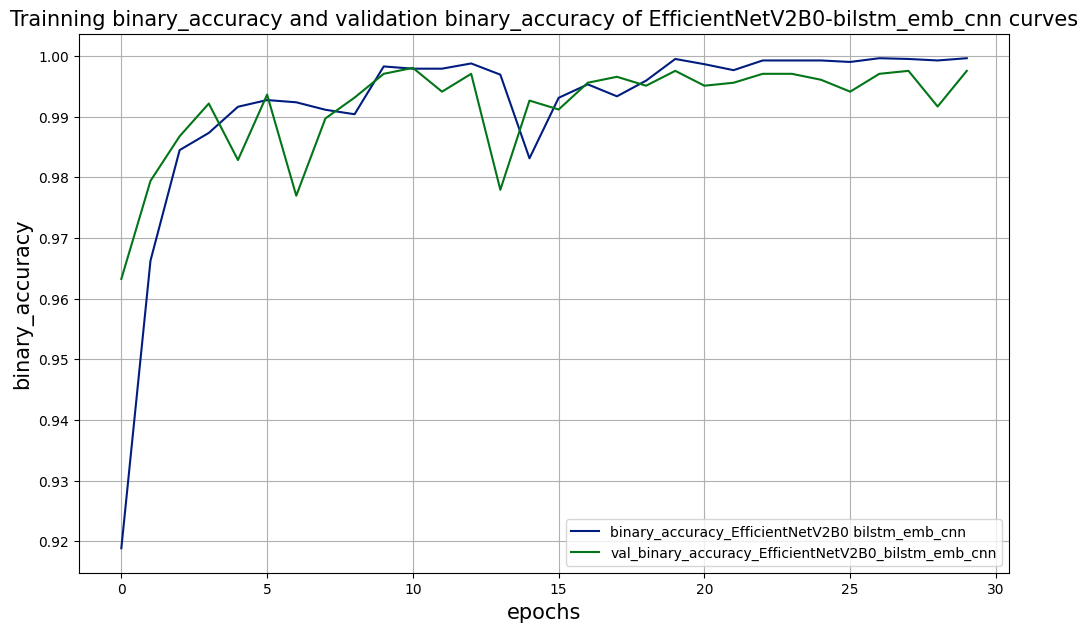

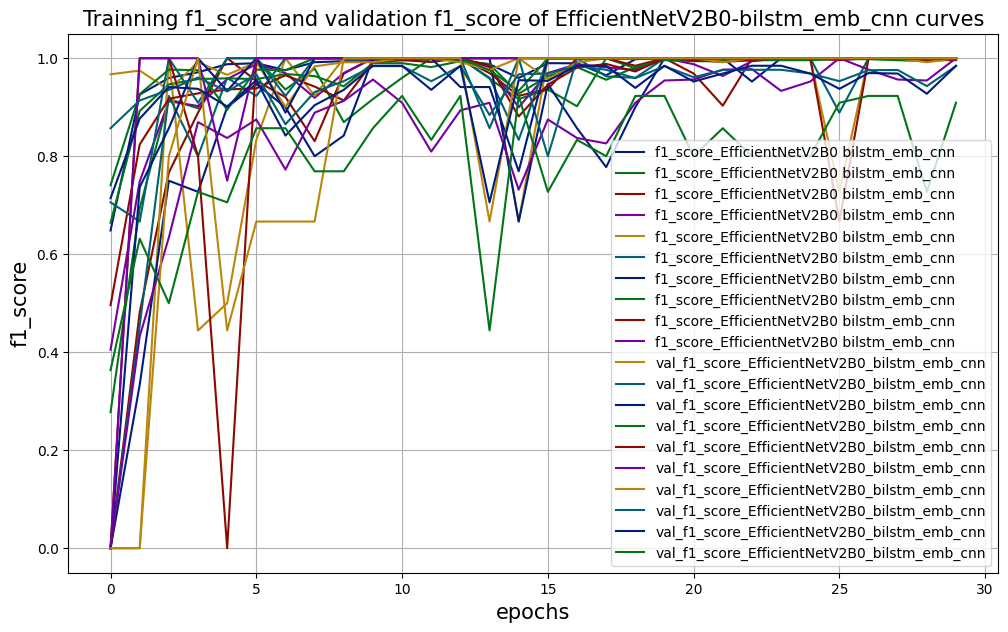

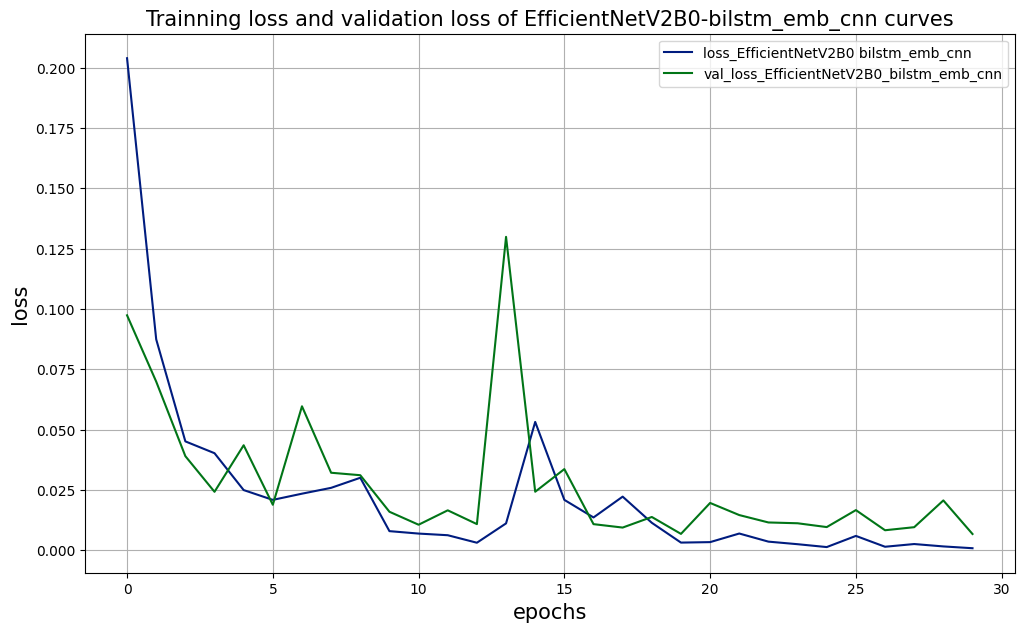

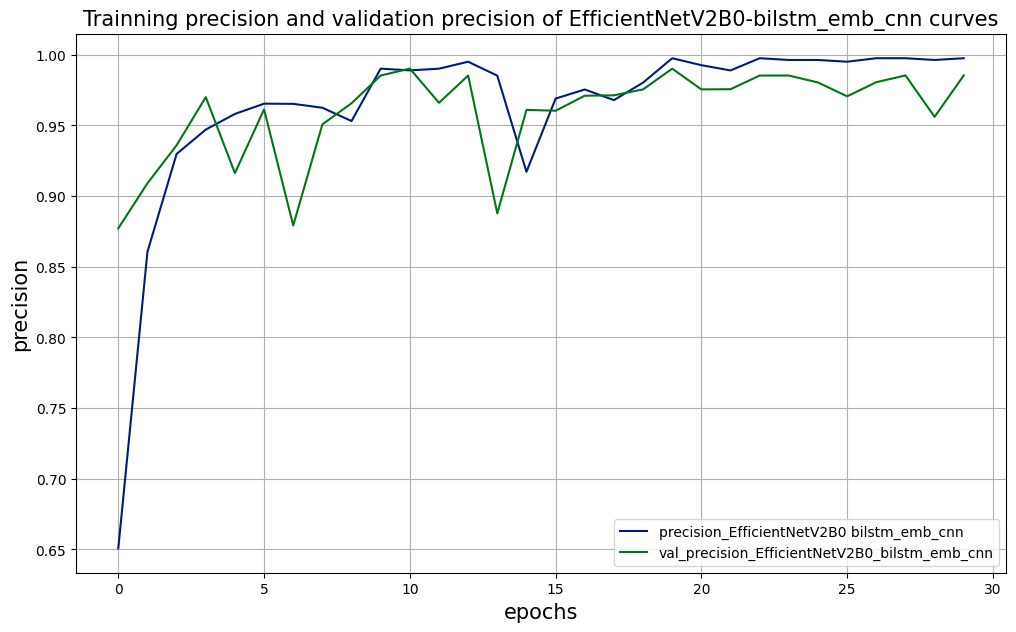

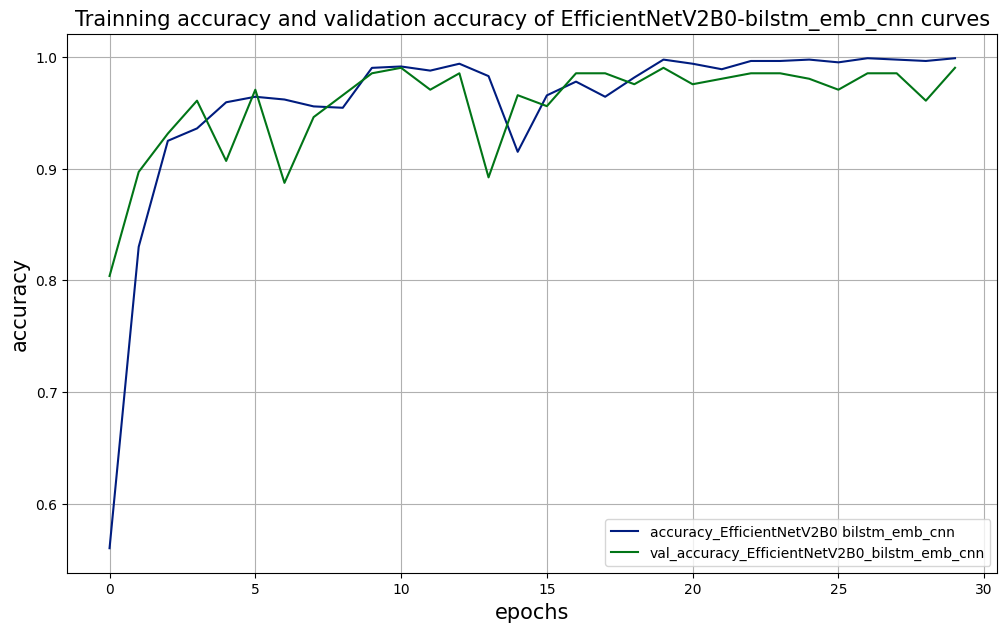

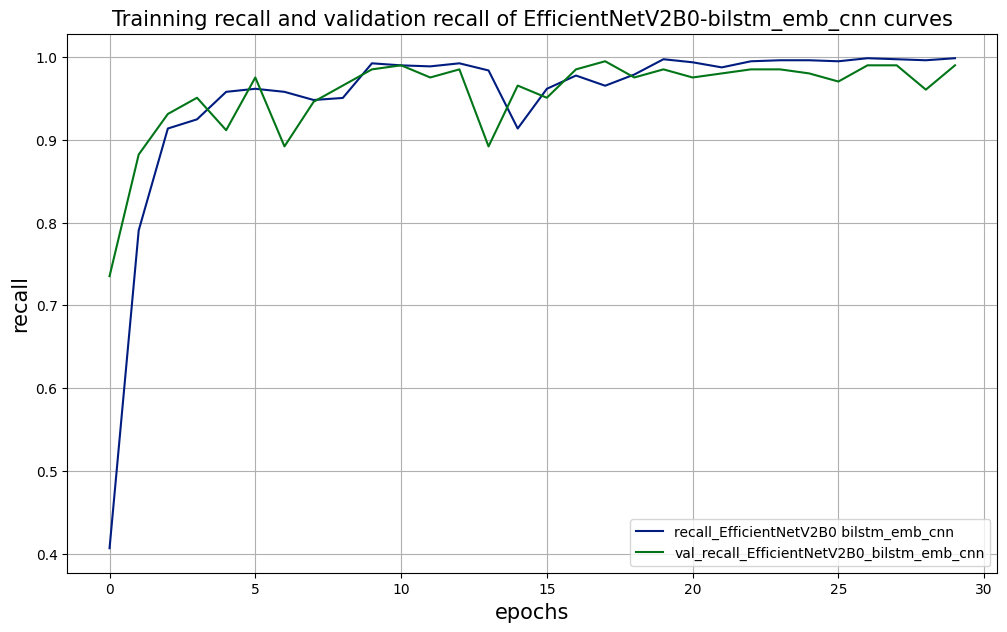

In [58]:
plt.style.use('seaborn-dark-palette')
for key in keys:
    plt.figure(figsize=(12,7))
    plt.plot(history.history[f'{key}'],label=f'{key}_EfficientNetV2B0 bilstm_emb_cnn',)
    plt.legend()
    plt.plot(history.history[f'val_{key}'],label=f'val_{key}_EfficientNetV2B0_bilstm_emb_cnn')
    plt.legend()
    plt.title(f'Trainning {key} and validation {key} of EfficientNetV2B0-bilstm_emb_cnn curves',fontsize=15)
    plt.xlabel('epochs',fontsize=15)
    plt.grid()
    plt.ylabel(key,fontsize=15)

In [59]:
res0_train=model.evaluate(train_gen)
res0_train

51/51 ━━━━━━━━━━━━━━━━━━━━ 47s 257ms/step - accuracy: 0.9990 - binary_accuracy: 0.9999 - f1_score: 0.9942 - loss: 3.6587e-04 - precision: 0.9990 - recall: 0.9998


[0.0005093872896395624,
 <tf.Tensor: shape=(10,), dtype=float32, numpy=
 array([1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 0.99797976, 1.        , 0.9777777 ],
       dtype=float32)>,
 0.9987684488296509,
 0.9987684488296509,
 0.9987684488296509,
 0.9997537732124329]

51/51 ━━━━━━━━━━━━━━━━━━━━ 50s 496ms/step


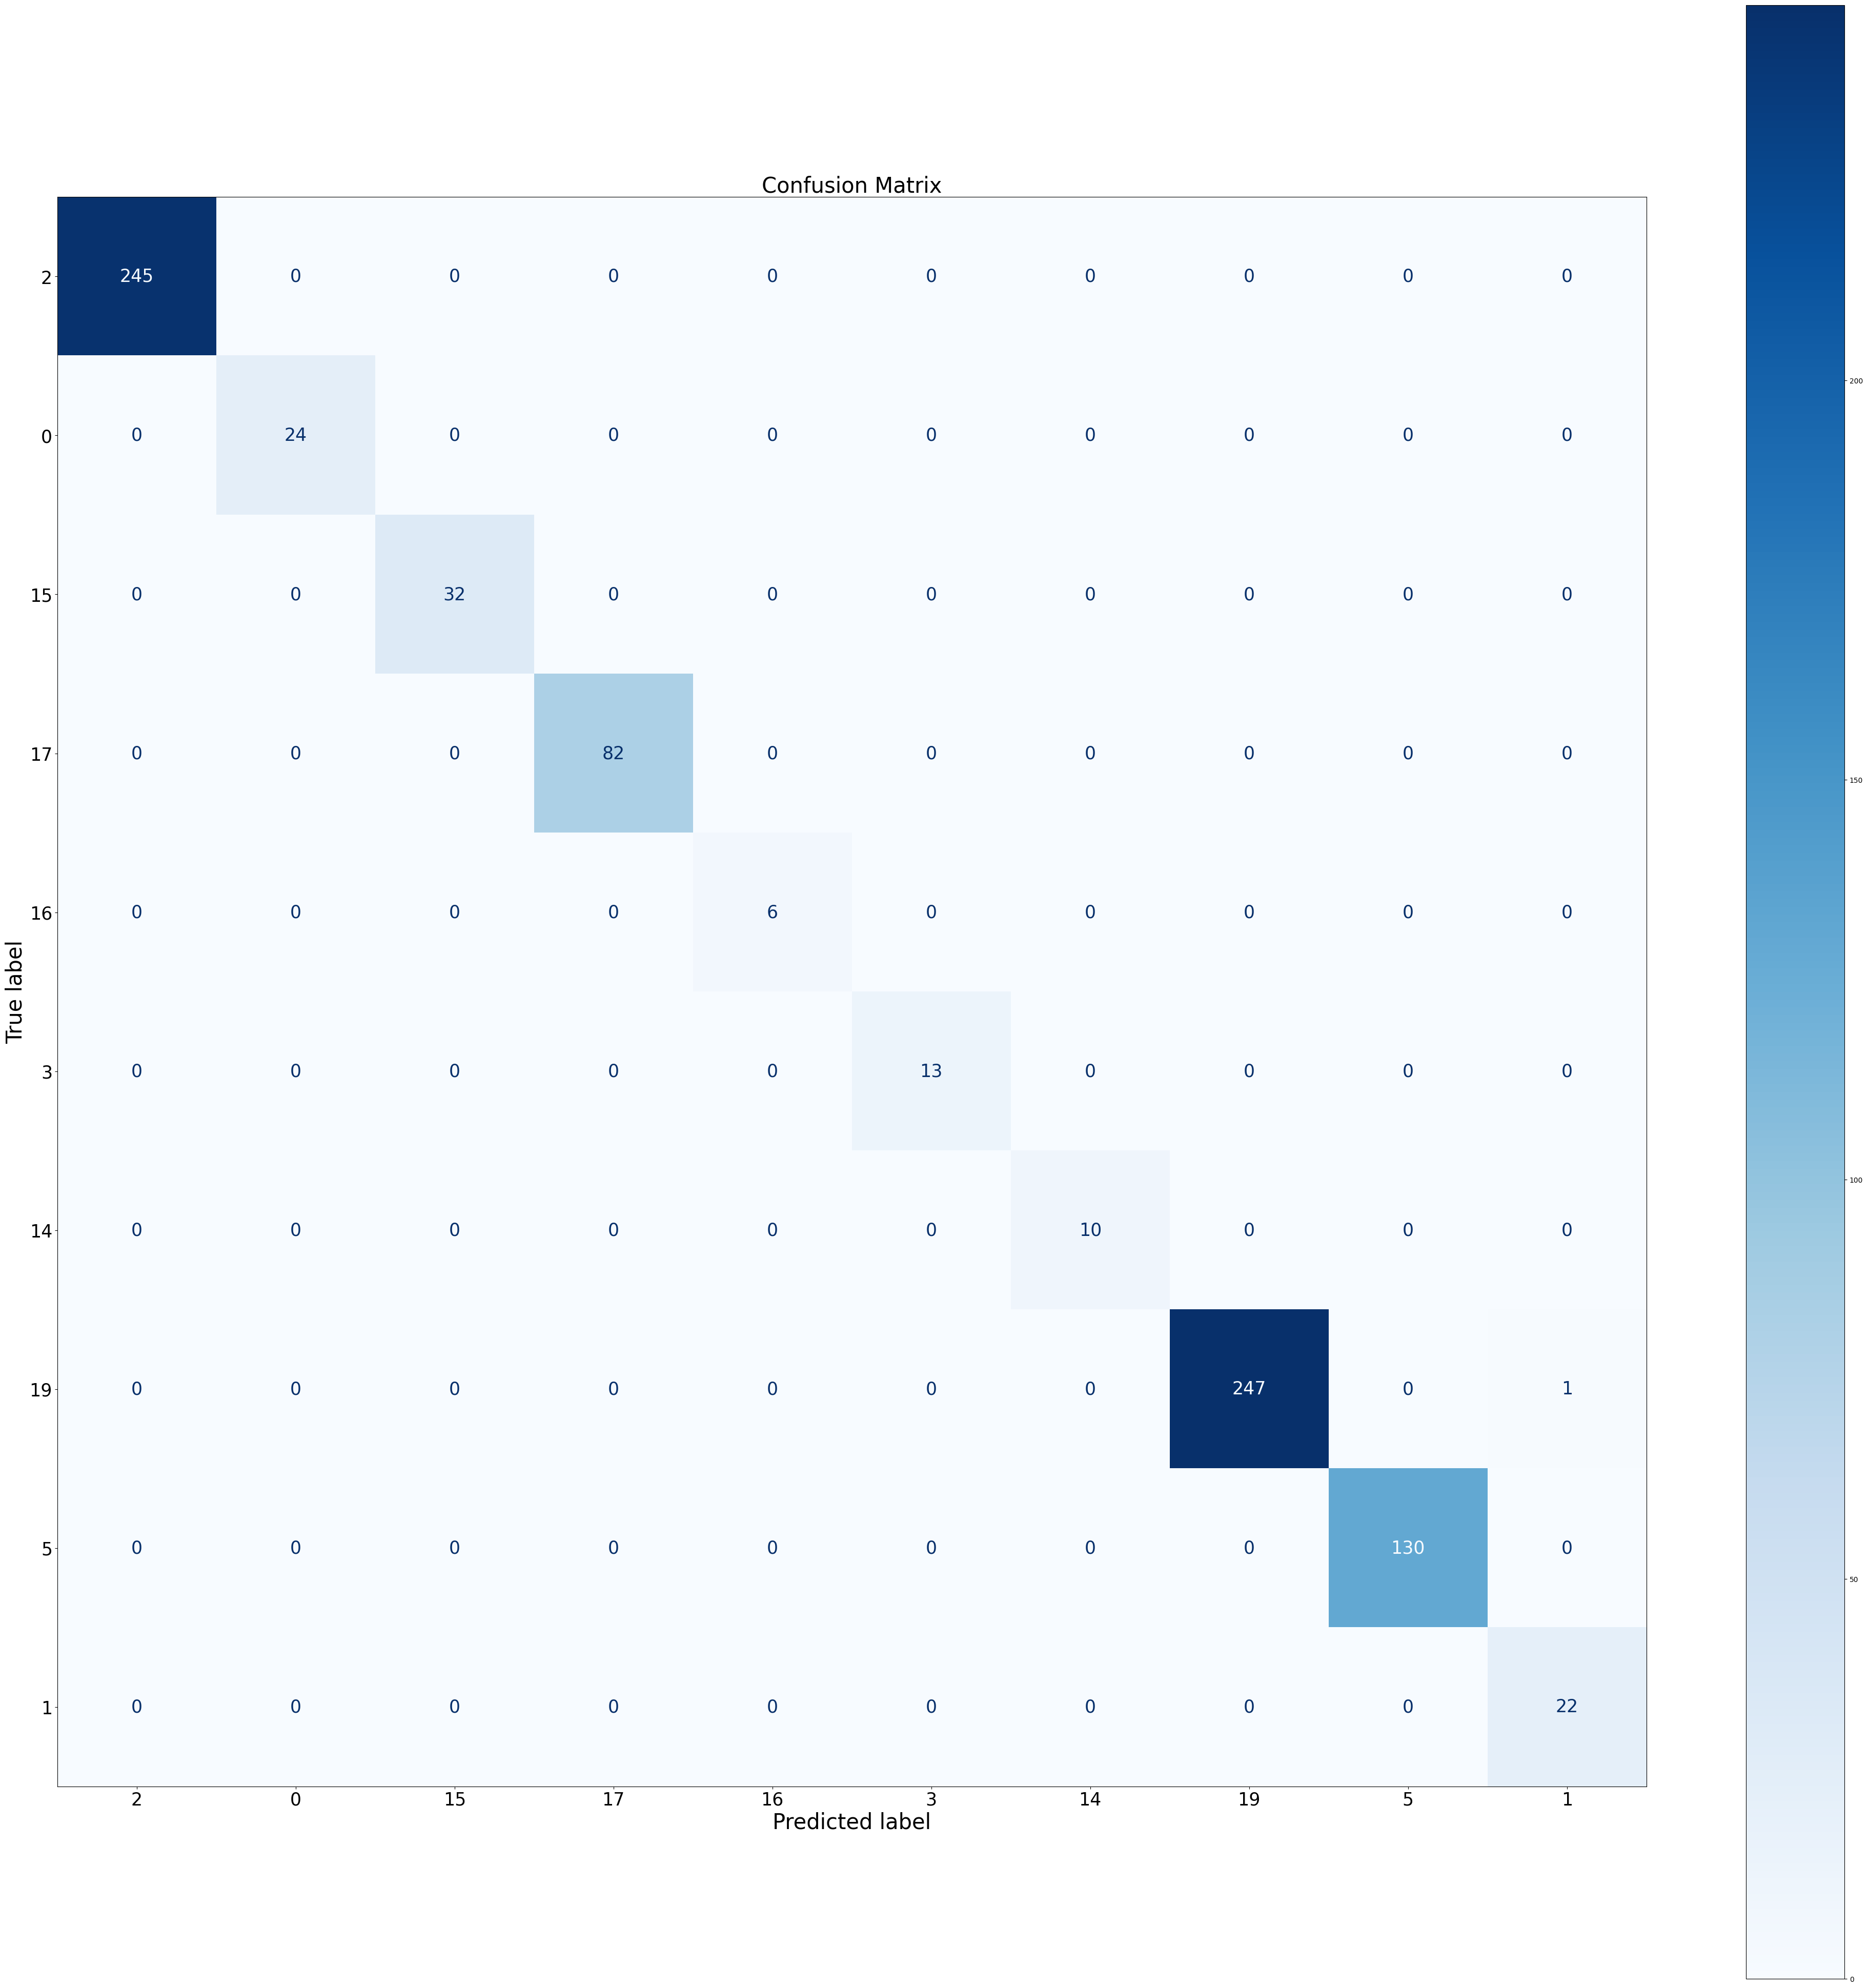

In [60]:
Y_res0_train= model.predict(train_gen)
Y_res0_train=[REFS_LABELS_MAP[np.argmax(y)] for y in Y_res0_train]
y_train_classes=[REFS_LABELS_MAP[y] for y in train_gen.labels]
cm=confusion_matrix(y_train_classes,Y_res0_train)
from sklearn.metrics import ConfusionMatrixDisplay
cmd = ConfusionMatrixDisplay(cm,display_labels=REFS_LABELS_MAP.values())
fig, ax = plt.subplots(figsize=(50, 50))  # Adjusted size for better readability
plt.xticks(fontsize=25)  # Set font size for x-axis labels
plt.yticks(fontsize=25)  # Set font size for y-axis labels
plt.xlabel("Predicted Label", fontsize=30)
plt.ylabel("True Label", fontsize=30)
plt.title("Confusion Matrix", fontsize=30)
cmd.plot(cmap='Blues',ax=ax)
for i in range(len(cmd.text_)):
    for j in range(len(cmd.text_[i])):
        cmd.text_[i][j].set_fontsize(25)  # Set the font size for the numbers inside the cells

plt.show()

In [61]:
from sklearn.metrics import classification_report
repport =classification_report(y_train_classes,Y_res0_train)
print(repport)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       245
           1       1.00      1.00      1.00        24
          14       1.00      1.00      1.00        32
          15       1.00      1.00      1.00        82
          16       1.00      1.00      1.00         6
          17       1.00      1.00      1.00        13
          19       1.00      1.00      1.00        10
           2       1.00      1.00      1.00       248
           3       1.00      1.00      1.00       130
           5       0.96      1.00      0.98        22

    accuracy                           1.00       812
   macro avg       1.00      1.00      1.00       812
weighted avg       1.00      1.00      1.00       812



##  shuffle=False in the test_gen:

In [62]:
test_gen=generator.flow_from_dataframe(
    dataframe=test_df,
    directory='/',
    x_col='path',
    y_col='label',
    class_mode='categorical',
    color_mode='rgb',
    batch_size=16,
    target_size=(128,256),
    shuffle=False
)

Found 204 validated image filenames belonging to 10 classes.


In [63]:
res0_test=model.evaluate(test_gen)
res0_test

 6/13 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 1.0000 - binary_accuracy: 1.0000 - f1_score: 0.7167 - loss: 0.0011 - precision: 1.0000 - recall: 1.0000    

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9965 - binary_accuracy: 0.9991 - f1_score: 0.8753 - loss: 0.0033 - precision: 0.9946 - recall: 0.9965


[0.006759583484381437,
 <tf.Tensor: shape=(10,), dtype=float32, numpy=
 array([1.       , 1.       , 1.       , 1.       , 1.       , 1.       ,
        1.       , 0.9841269, 0.9846153, 0.9090909], dtype=float32)>,
 0.9853658676147461,
 0.9901960492134094,
 0.9901960492134094,
 0.9975489974021912]

In [64]:
len(CLASS_NAMES)

10

### Metrics

#### Confusion Matrix

In [65]:
test_gen.class_indices

{'0': 0,
 '1': 1,
 '2': 2,
 '3': 3,
 '4': 4,
 '5': 5,
 '6': 6,
 '7': 7,
 '8': 8,
 '9': 9}

In [66]:
REFS_LABELS_MAP

{7: '2',
 0: '0',
 3: '15',
 5: '17',
 4: '16',
 8: '3',
 2: '14',
 6: '19',
 9: '5',
 1: '1'}

In [67]:
Y_res0_test= model.predict(test_gen)
Y_res0_test=[np.argmax(y) for y in Y_res0_test]

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


In [68]:
Y_res0_test[10:20],test_gen.labels[10:20]

([3, 0, 0, 8, 8, 7, 7, 7, 7, 7], [3, 0, 0, 8, 8, 7, 7, 7, 7, 7])

In [69]:
test_gen.filenames[:10]

['/kaggle/input/5-arabic-roots/corpus1/74/2/nom/2/4_feminin/7_marfou3/Image_24_Arabic Transparent_1466.png',
 '/kaggle/input/5-arabic-roots/corpus1/76/2/nom/1/4_feminin/Image_14_Arabic Transparent_1146.png',
 '/kaggle/input/5-arabic-roots/corpus1/76/2/5_pass�/10_moukhatab/1_antom/Image_18_Arabic Transparent_3.png',
 '/kaggle/input/5-arabic-roots/corpus1/74/0/5_pass�/10_moukhatab/2_antonna/Image_18_Arabic Transparent_859.png',
 '/kaggle/input/5-arabic-roots/corpus1/76/15/nom/1/4_feminin/Image_24_Arabic Transparent_946_2.png',
 '/kaggle/input/5-arabic-roots/corpus1/74/3/5_pass�/10_moukhatab/0_antouma/Image_14_Arabic Transparent_1628.png',
 '/kaggle/input/5-arabic-roots/corpus1/74/3/6_pr�sent/10_moukhatab/1_anta/Image_18_Arabic Transparent_1528.png',
 '/kaggle/input/5-arabic-roots/corpus1/34/0/5_pass�/11_ghaeb/4_hom/Image_14_Arabic Transparent_2139.png',
 '/kaggle/input/5-arabic-roots/corpus1/34/3/6_pr�sent/10_moukhatab/3_antom/Image_14_Arabic Transparent_2135.png',
 '/kaggle/input/5-arab

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


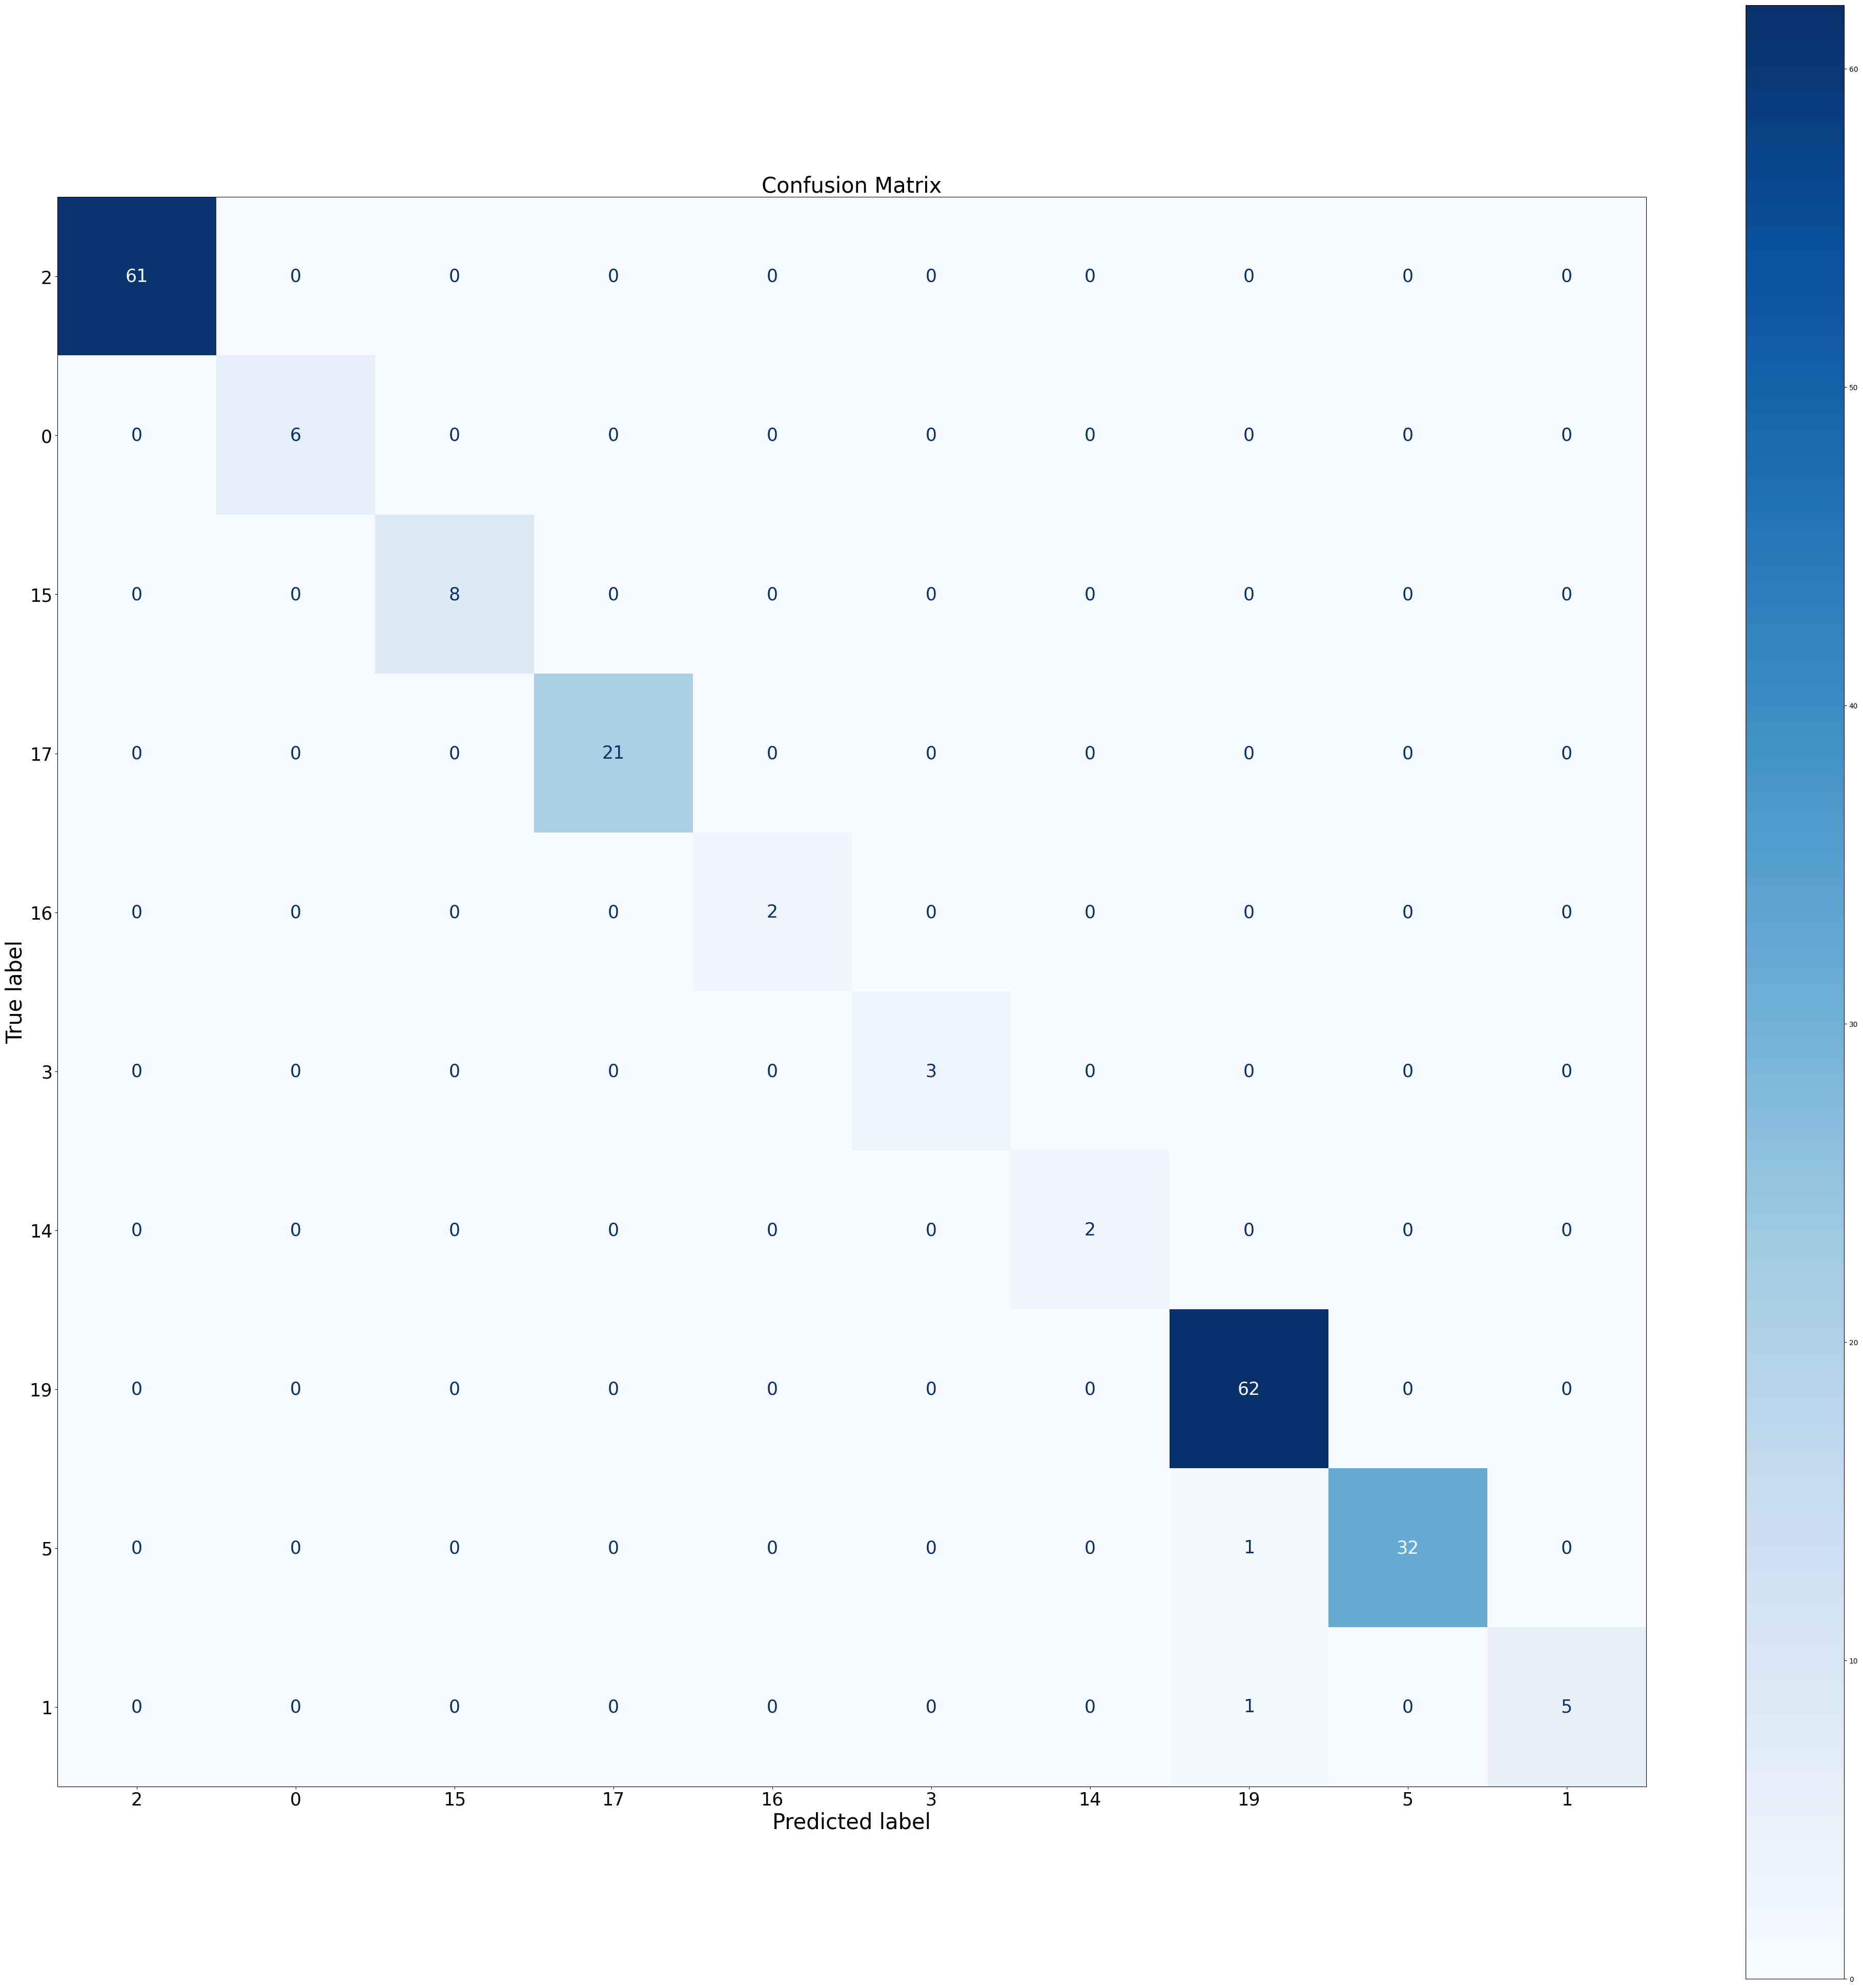

In [70]:
Y_res0_test= model.predict(test_gen)
Y_res0_test=[REFS_LABELS_MAP[np.argmax(y)] for y in Y_res0_test]
y_test_classes=[REFS_LABELS_MAP[y] for y in test_gen.labels]
cm=confusion_matrix(y_test_classes,Y_res0_test)
from sklearn.metrics import ConfusionMatrixDisplay
cmd = ConfusionMatrixDisplay(cm,display_labels=REFS_LABELS_MAP.values())
fig, ax = plt.subplots(figsize=(50, 50))  # Adjusted size for better readability
plt.xticks(fontsize=25)  # Set font size for x-axis labels
plt.yticks(fontsize=25)  # Set font size for y-axis labels
plt.xlabel("Predicted Label", fontsize=30)
plt.ylabel("True Label", fontsize=30)
plt.title("Confusion Matrix", fontsize=30)
cmd.plot(cmap='Blues',ax=ax)
for i in range(len(cmd.text_)):
    for j in range(len(cmd.text_[i])):
        cmd.text_[i][j].set_fontsize(25)  # Set the font size for the numbers inside the cells

plt.show()

#### Classification report

In [71]:
from sklearn.metrics import classification_report
repport =classification_report(y_test_classes,Y_res0_test)
print(repport)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        61
           1       1.00      1.00      1.00         6
          14       1.00      1.00      1.00         8
          15       1.00      1.00      1.00        21
          16       1.00      1.00      1.00         2
          17       1.00      1.00      1.00         3
          19       1.00      1.00      1.00         2
           2       0.97      1.00      0.98        62
           3       1.00      0.97      0.98        33
           5       1.00      0.83      0.91         6

    accuracy                           0.99       204
   macro avg       1.00      0.98      0.99       204
weighted avg       0.99      0.99      0.99       204



#### Top-5 accuracy

In [72]:
from sklearn.metrics import top_k_accuracy_score
y_test_scores=model.predict(test_gen)
top_5_accuracy=top_k_accuracy_score(test_gen.labels,y_test_scores,k=5)
print("the Top 5 accuracy score: "+ str(top_5_accuracy))

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
the Top 5 accuracy score: 1.0


### Wrong test predictions 

Error at index 138: not a PNG file


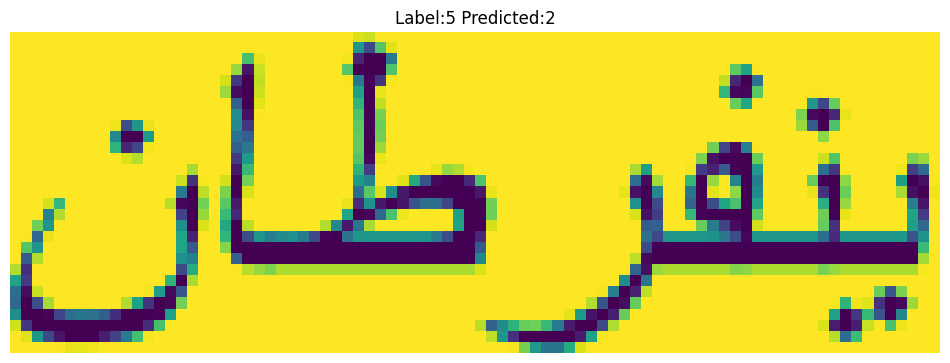

In [73]:
for index in range(len(Y_res0_test)):
    try:
        if Y_res0_test[index] != y_test_classes[index]:
            img = plt.imread(test_df['path'].values[index])
            plt.figure(figsize=(12, 6))
            plt.title(
                "Label:" + y_test_classes[index] +
                " Predicted:" + Y_res0_test[index]
            )
            plt.imshow(img)
            plt.axis("off")
            plt.show()
    except Exception as e:
        print(f"Error at index {index}: {e}")
        continue


## 2. Custom Bilstm:

In [74]:
@tf.keras.utils.register_keras_serializable(package="Custom2")
class MyLSTM(tf.keras.layers.Layer):
    def __init__(self,units,return_sequences=False, **kwargs):
        super(MyLSTM, self).__init__(**kwargs)
        self.units=units
        self.return_sequences = return_sequences
        
    def build(self,input_shape):
        nb_features=input_shape[-1]
        self.input_dim = input_shape[-1]

        ## Weights of the first lstm layer
        
        self.wi= self.add_weight(shape=(self.units,self.units),initializer="glorot_uniform",name="wi")
        self.ui= self.add_weight(shape=(nb_features,self.units),initializer="orthogonal", name="ui")
        self.bi= self.add_weight(shape=(self.units,) , initializer="zeros",name="bi")
        self.wf= self.add_weight(shape=(self.units,self.units),initializer="glorot_uniform",name="wf")
        self.uf= self.add_weight(shape=(nb_features,self.units),initializer="orthogonal", name="uf")
        self.bf= self.add_weight(shape=(self.units,) , initializer="zeros",name="bf")

        self.wc= self.add_weight(shape=(self.units,self.units),initializer="glorot_uniform",name="wc")
        self.uc= self.add_weight(shape=(nb_features,self.units),initializer="orthogonal", name="uc")
        self.bc= self.add_weight(shape=(self.units,) , initializer="zeros",name="bc")

        self.wo= self.add_weight(shape=(self.units,self.units),initializer="glorot_uniform",name="wo")
        self.uo= self.add_weight(shape=(nb_features,self.units),initializer="orthogonal", name="uo")
        self.bo= self.add_weight(shape=(self.units,) , initializer="zeros",name="bo")   


        ## Weights of the second lstm layer
        self.wi2= self.add_weight(shape=(self.units,self.units),initializer="glorot_uniform",name="wi2")
        self.ui2= self.add_weight(shape=(nb_features,self.units),initializer="orthogonal", name="ui2")
        self.bi2= self.add_weight(shape=(self.units,) , initializer="zeros",name="bi2")

        self.wf2= self.add_weight(shape=(self.units,self.units),initializer="glorot_uniform",name="wf2")
        self.uf2= self.add_weight(shape=(nb_features,self.units),initializer="orthogonal", name="uf2")
        self.bf2= self.add_weight(shape=(self.units,) , initializer="zeros",name="bf2")

        self.wc2= self.add_weight(shape=(self.units,self.units),initializer="glorot_uniform",name="wc2")
        self.uc2= self.add_weight(shape=(nb_features,self.units),initializer="orthogonal", name="uc2")
        self.bc2= self.add_weight(shape=(self.units,) , initializer="zeros",name="bc2")

        self.wo2= self.add_weight(shape=(self.units,self.units),initializer="glorot_uniform",name="wo2")
        self.uo2= self.add_weight(shape=(nb_features,self.units),initializer="orthogonal", name="uo2")
        self.bo2= self.add_weight(shape=(self.units,) , initializer="zeros",name="bo2")   

    def call(self,inputs):
        timesteps = inputs.shape[1]
        batch_size = tf.shape(inputs)[0]
        ht = tf.zeros((batch_size, self.units))
        ct = tf.zeros((batch_size, self.units))
        hn_t = tf.zeros((batch_size, self.units))
        cn_t = tf.zeros((batch_size, self.units))
        state=[ht,ct,hn_t,cn_t]
        outputs=[]
        hts=[] # hsitory of the ht
        hn_ts=[] # hsitory of the hn_t
        for t in range(timesteps):
            ht_1=  tf.reshape(ht, [-1, self.units])
            ct_1= state[1]
            hn_t_1=  tf.reshape(hn_t, [-1, self.units])
            cn_t_1= state[3]
            # forward
            xt = inputs[:,t,:]
            i = tf.sigmoid(tf.matmul(ht_1,self.wi) +tf.matmul(xt,self.ui)+self.bi)
            f = tf.sigmoid(tf.matmul(ht_1,self.wf) + tf.matmul(xt,self.uf)+ self.bf)
            c_hat = tf.tanh(tf.matmul(ht_1,self.wc)+ tf.matmul(xt,self.uc) + self.bc)
            o = tf.sigmoid(tf.matmul(ht_1,self.wo)+tf.matmul(xt,self.uo) + self.bo)
            ct = ct_1*f + i*c_hat
            ht = o*tf.tanh(ct)
            hts.append(ht);
            #backword
            xn_t = inputs[:,timesteps - t - 1,:]
            in_t = tf.sigmoid(tf.matmul(hn_t_1,self.wi2) +tf.matmul(xn_t,self.ui2)+self.bi2)
            fn_t = tf.sigmoid(tf.matmul(hn_t_1,self.wf2) + tf.matmul(xn_t,self.uf2)+ self.bf2)
            cn_t_hat = tf.tanh(tf.matmul(hn_t_1,self.wc2)+ tf.matmul(xn_t,self.uc2) + self.bc2)
            on_t = tf.sigmoid(tf.matmul(hn_t_1,self.wo2)+tf.matmul(xn_t,self.uo2) + self.bo2)
            cn_t = cn_t_1*fn_t + in_t*cn_t_hat
            hn_t = on_t*tf.tanh(cn_t)
            hn_ts.append(hn_t);
            # if self.return_sequences:
            #     outputs.append(tf.concat([ht,hn_t],axis=1))
            state=[ht,ct,hn_t,cn_t]

        if self.return_sequences:
            # for t in range(timesteps):
            #     outputs.append(tf.concat([ht,hn_t],axis=1))                
            concat_hts=[]
            for i in range(timesteps-1): # from 0 to timesteps - 2
                concat_hts.append(tf.concat([hts[i],hts[i+1]],axis=1))
            concat_hts.append(tf.concat([hts[timesteps-1] , tf.zeros((batch_size, self.units))],axis=1)) # 1
            concat_ht_ts=[]

            for i in range(1,timesteps): # from 1 to timesteps - 1
                concat_ht_ts.append(tf.concat([hn_ts[timesteps-i-1] , hn_ts[timesteps-i]],axis=1))
            concat_ht_ts.append(tf.concat([tf.zeros((batch_size, self.units)),hn_ts[0]],axis=1)) # 0
            for i in range(timesteps):
                outputs.append(tf.concat([concat_hts[i],concat_ht_ts[i]],axis=1))
            return tf.stack(outputs,axis=1)

        else: 
            return state[0]
            
    def get_config(self):
        config = super().get_config()
        config.update({
            "return_sequences": self.return_sequences,
            "units": self.units,
        })
        return config 

In [75]:
backbone= EfficientNetV2B0(weights='imagenet',include_top=False,input_shape=(128, 256, 3))
input_data = backbone.input 
inner = backbone.output
# CNN to RNN
inner = Reshape(target_shape=(32,1280), name='reshape')(inner)
##  Bidirectional lstm from scratch : 
inner = MyLSTM(256, return_sequences=True, name = 'c_bilstm1')(inner)
inner = MyLSTM(256, return_sequences=False, name = 'c_bilstm2')(inner)

inner = Dense(1000, activation='relu', kernel_initializer='he_normal', name='dense2')(inner)
## OUTPUT
inner = Dense(NB_CLASSES, kernel_initializer='he_normal',name='dense3')(inner)
y_pred = Activation('sigmoid', name='sigmoid')(inner)
model = Model(inputs=input_data, outputs=y_pred)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 128, 256, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling_1 (Rescaling)   │ (None, 128, 256, 3)    │              0 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ normalization_1           │ (None, 128, 256, 3)    │              0 │ rescaling_1[0][0]      │
│ (Normalization)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv (Conv2D)        │ (None, 64, 128, 32)    │            864 │ normalization_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_bn                   │ (None, 64, 128, 32)    │            128 │ stem_conv[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_activation           │ (None, 64, 128, 32)    │              0 │ stem_bn[0][0]          │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_project_conv      │ (None, 64, 128, 16)    │          4,608 │ stem_activation[0][0]  │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_project_bn        │ (None, 64, 128, 16)    │             64 │ block1a_project_conv[… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_project_activati… │ (None, 64, 128, 16)    │              0 │ block1a_project_bn[0]… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2a_expand_conv       │ (None, 32, 64, 64)     │          9,216 │ block1a_project_activ… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2a_expand_bn         │ (None, 32, 64, 64)     │            256 │ block2a_expand_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2a_expand_activation │ (None, 32, 64, 64)     │              0 │ block2a_expand_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2a_project_conv      │ (None, 32, 64, 32)     │          2,048 │ block2a_expand_activa… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2a_project_bn        │ (None, 32, 64, 32)     │            128 │ block2a_project_conv[… │
│ (BatchNormalization) 

 Total params: 11,957,586 (45.61 MB)

 Trainable params: 11,896,978 (45.38 MB)

 Non-trainable params: 60,608 (236.75 KB)

In [76]:
model.compile(optimizer=Adam(LR),loss=LOSS_FUNCTION,metrics=metrics)

In [77]:
test_gen=generator.flow_from_dataframe(
    dataframe=test_df,
    directory='/',
    x_col='path',
    y_col='label',
    class_mode='categorical',
    color_mode='rgb',
    batch_size=16,
    target_size=(128,256),
    shuffle=True
)

Found 204 validated image filenames belonging to 10 classes.


In [78]:
history=model.fit(train_gen,validation_data=test_gen, steps_per_epoch=STEPS, epochs=EPOCHS,verbose=2)

Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/optimizers/base_optimizer.py:678: UserWarning: Gradients do not exist for variables ['wi2', 'ui2', 'bi2', 'wf2', 'uf2', 'bf2', 'wc2', 'uc2', 'bc2', 'wo2', 'uo2', 'bo2'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(
/usr/lib/python3.11/contextlib.py:158: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_

102/102 - 293s - 3s/step - accuracy: 0.5567 - binary_accuracy: 0.9332 - f1_score: 0.4555 - loss: 0.2128 - precision: 0.7119 - recall: 0.5571 - val_accuracy: 0.7549 - val_binary_accuracy: 0.9549 - val_f1_score: 0.4570 - val_loss: 0.1220 - val_precision: 0.8011 - val_recall: 0.7304
Epoch 2/30
102/102 - 4s - 37ms/step - accuracy: 0.8325 - binary_accuracy: 0.9665 - f1_score: 0.5677 - loss: 0.0849 - precision: 0.8659 - recall: 0.7869 - val_accuracy: 0.8676 - val_binary_accuracy: 0.9755 - val_f1_score: 0.6534 - val_loss: 0.0687 - val_precision: 0.8850 - val_recall: 0.8676
Epoch 3/30
102/102 - 4s - 36ms/step - accuracy: 0.9052 - binary_accuracy: 0.9809 - f1_score: 0.7297 - loss: 0.0551 - precision: 0.9185 - recall: 0.8879 - val_accuracy: 0.8186 - val_binary_accuracy: 0.9652 - val_f1_score: 0.5569 - val_loss: 0.0863 - val_precision: 0.8482 - val_recall: 0.7941
Epoch 4/30
102/102 - 4s - 36ms/step - accuracy: 0.9236 - binary_accuracy: 0.9845 - f1_score: 0.8211 - loss: 0.0425 - precision: 0.9277 

In [79]:
model.save("Schema_30_ep_5roots_c_bi_fb_lstm.keras")

In [80]:
model=tf.keras.models.load_model("/kaggle/working/Schema_30_ep_5roots_c_bi_fb_lstm.keras")

In [81]:
np.save("Schema_30_ep_5roots_c_bi_fb_lstm_training_history.npy", history.history, allow_pickle=True)

In [82]:
history.history.keys()

dict_keys(['accuracy', 'binary_accuracy', 'f1_score', 'loss', 'precision', 'recall', 'val_accuracy', 'val_binary_accuracy', 'val_f1_score', 'val_loss', 'val_precision', 'val_recall'])

In [83]:
keys=['binary_accuracy','f1_score','loss','precision', 'accuracy','recall']

/tmp/ipykernel_20/1257161458.py:1: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-dark-palette')


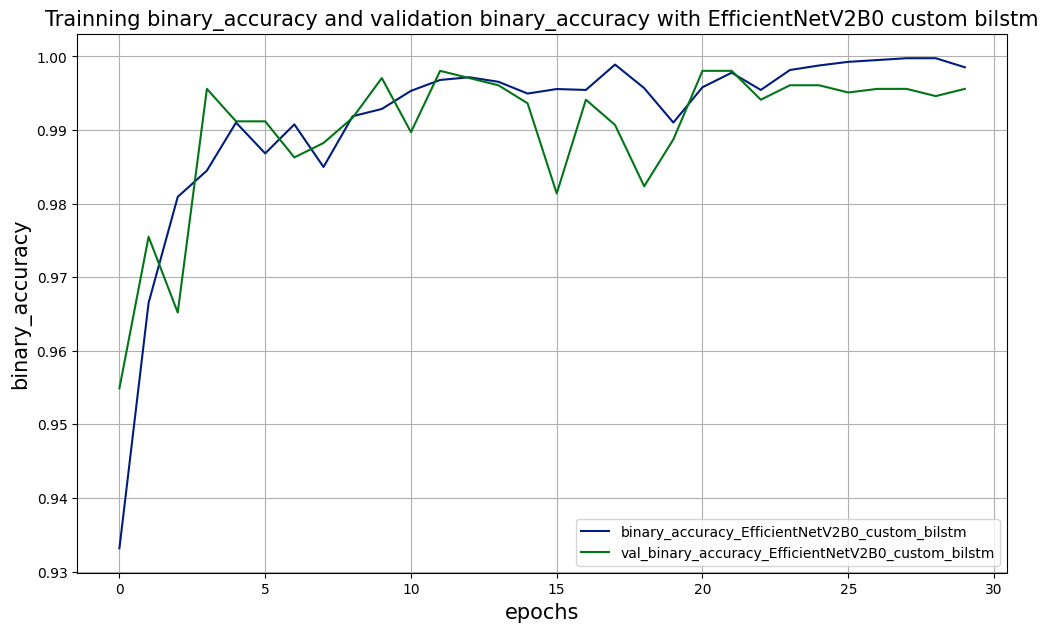

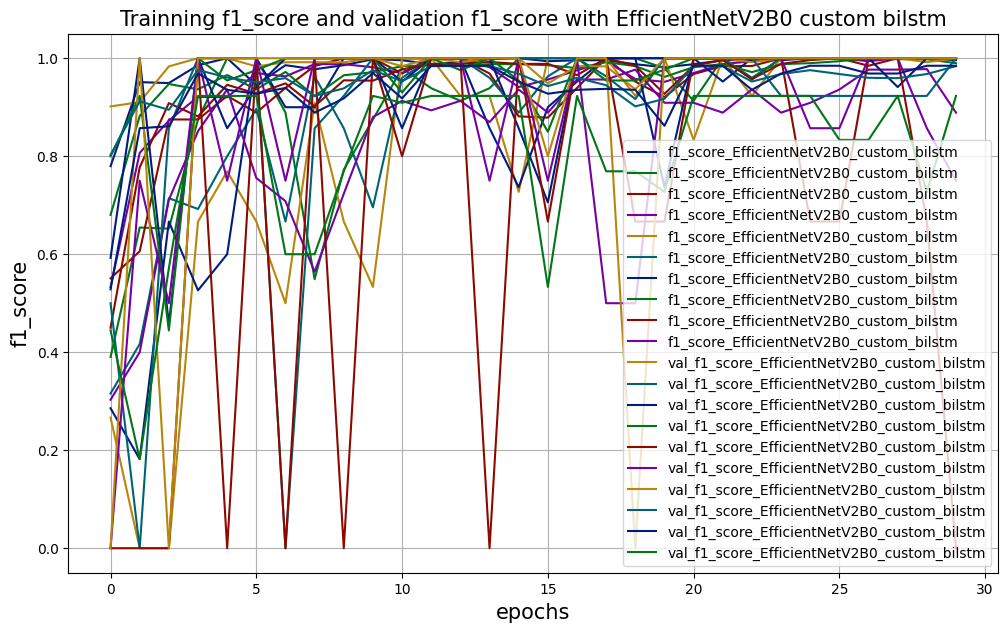

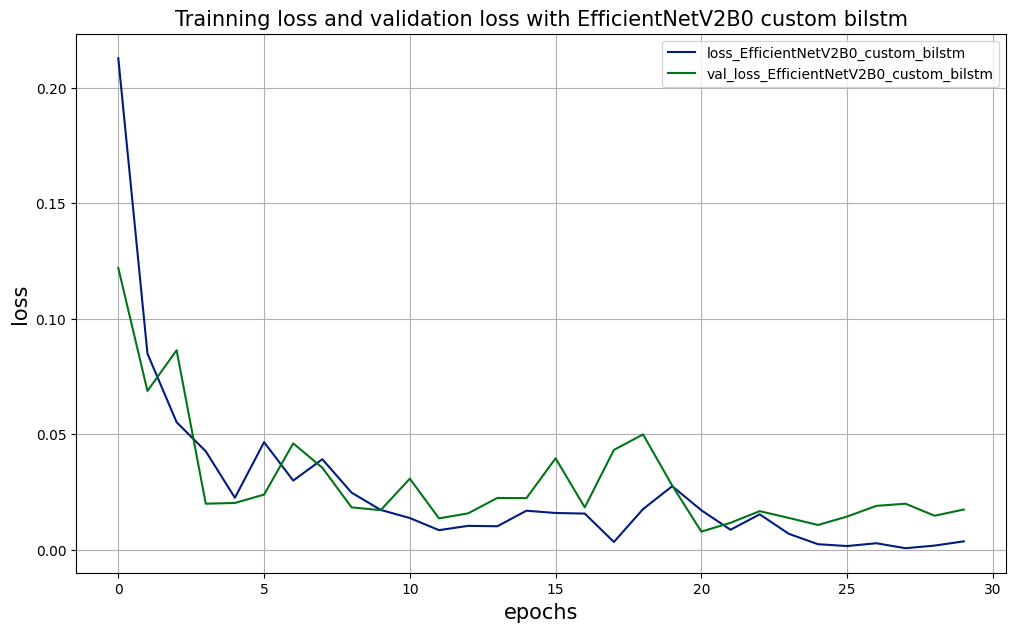

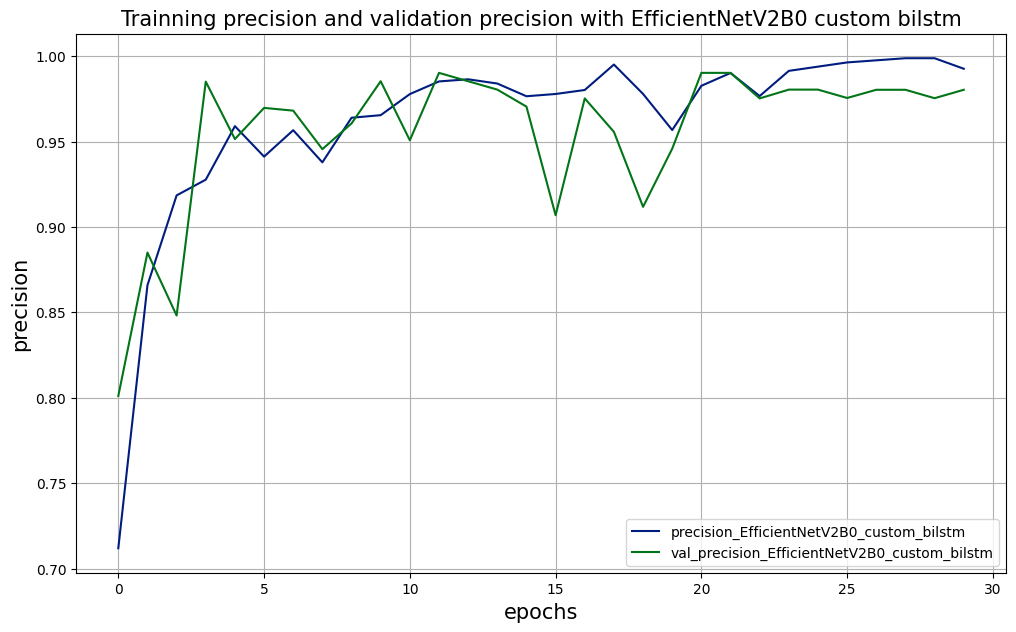

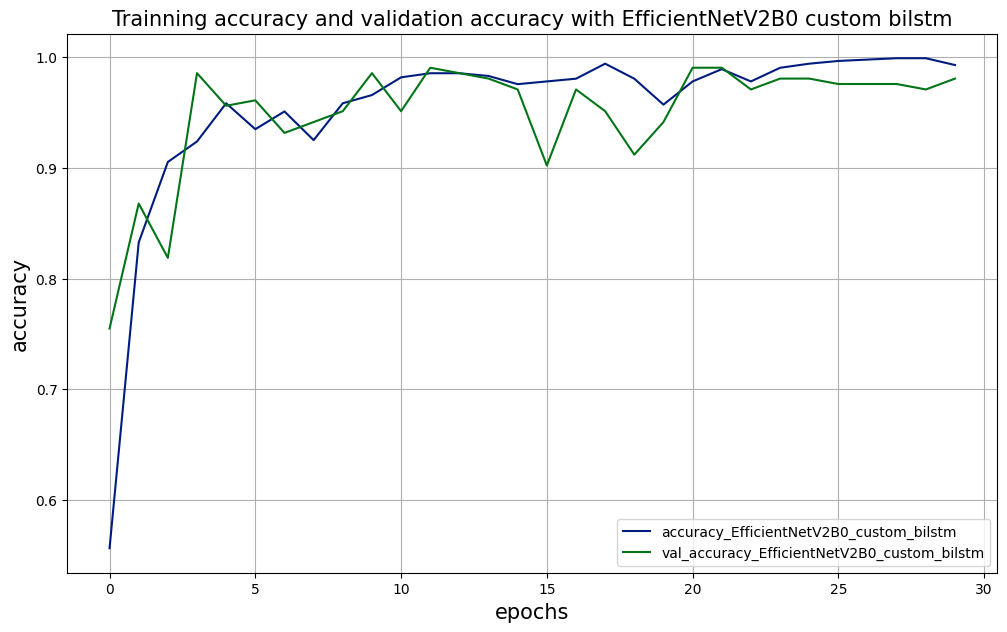

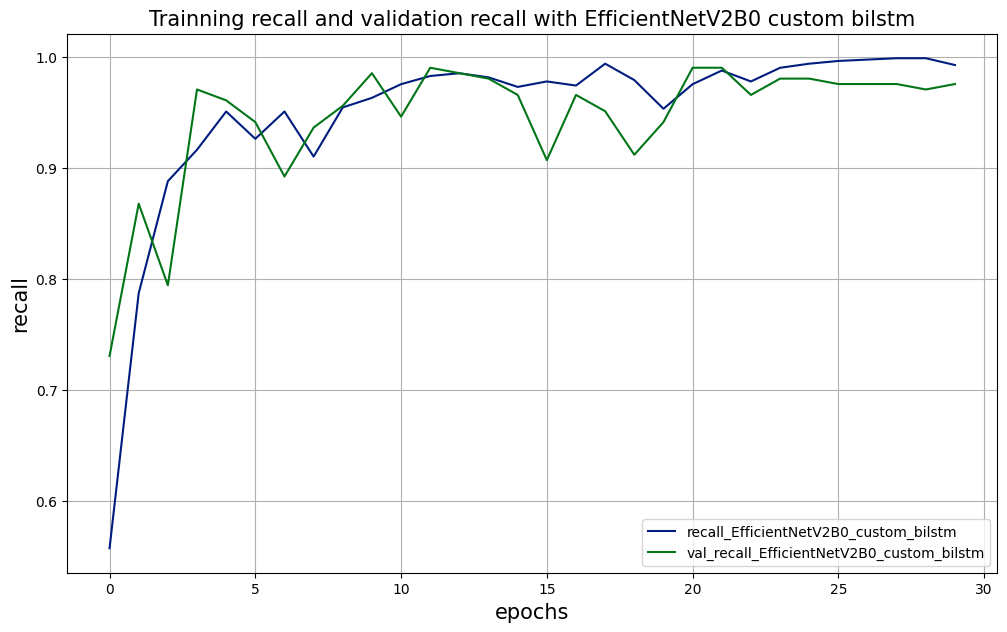

In [84]:
plt.style.use('seaborn-dark-palette')
for key in keys:
    plt.figure(figsize=(12,7))
    plt.plot(history.history[f'{key}'],label=f'{key}_EfficientNetV2B0_custom_bilstm')
    plt.legend()
    plt.plot(history.history[f'val_{key}'],label=f'val_{key}_EfficientNetV2B0_custom_bilstm')
    plt.legend()
    plt.title(f'Trainning {key} and validation {key} with EfficientNetV2B0 custom bilstm',fontsize=15)
    plt.xlabel('epochs',fontsize=15)
    plt.grid()
    plt.ylabel(key,fontsize=15)

In [85]:
res0_train=model.evaluate(train_gen)
res0_train

51/51 ━━━━━━━━━━━━━━━━━━━━ 45s 222ms/step - accuracy: 0.9961 - binary_accuracy: 0.9992 - f1_score: 0.9889 - loss: 8.8932e-04 - precision: 0.9961 - recall: 0.9961


[0.001035958412103355,
 <tf.Tensor: shape=(10,), dtype=float32, numpy=
 array([1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 0.9939148 , 1.        , 0.93617016],
       dtype=float32)>,
 0.9963054060935974,
 0.9963054060935974,
 0.9963054060935974,
 0.9992610216140747]

51/51 ━━━━━━━━━━━━━━━━━━━━ 44s 489ms/step


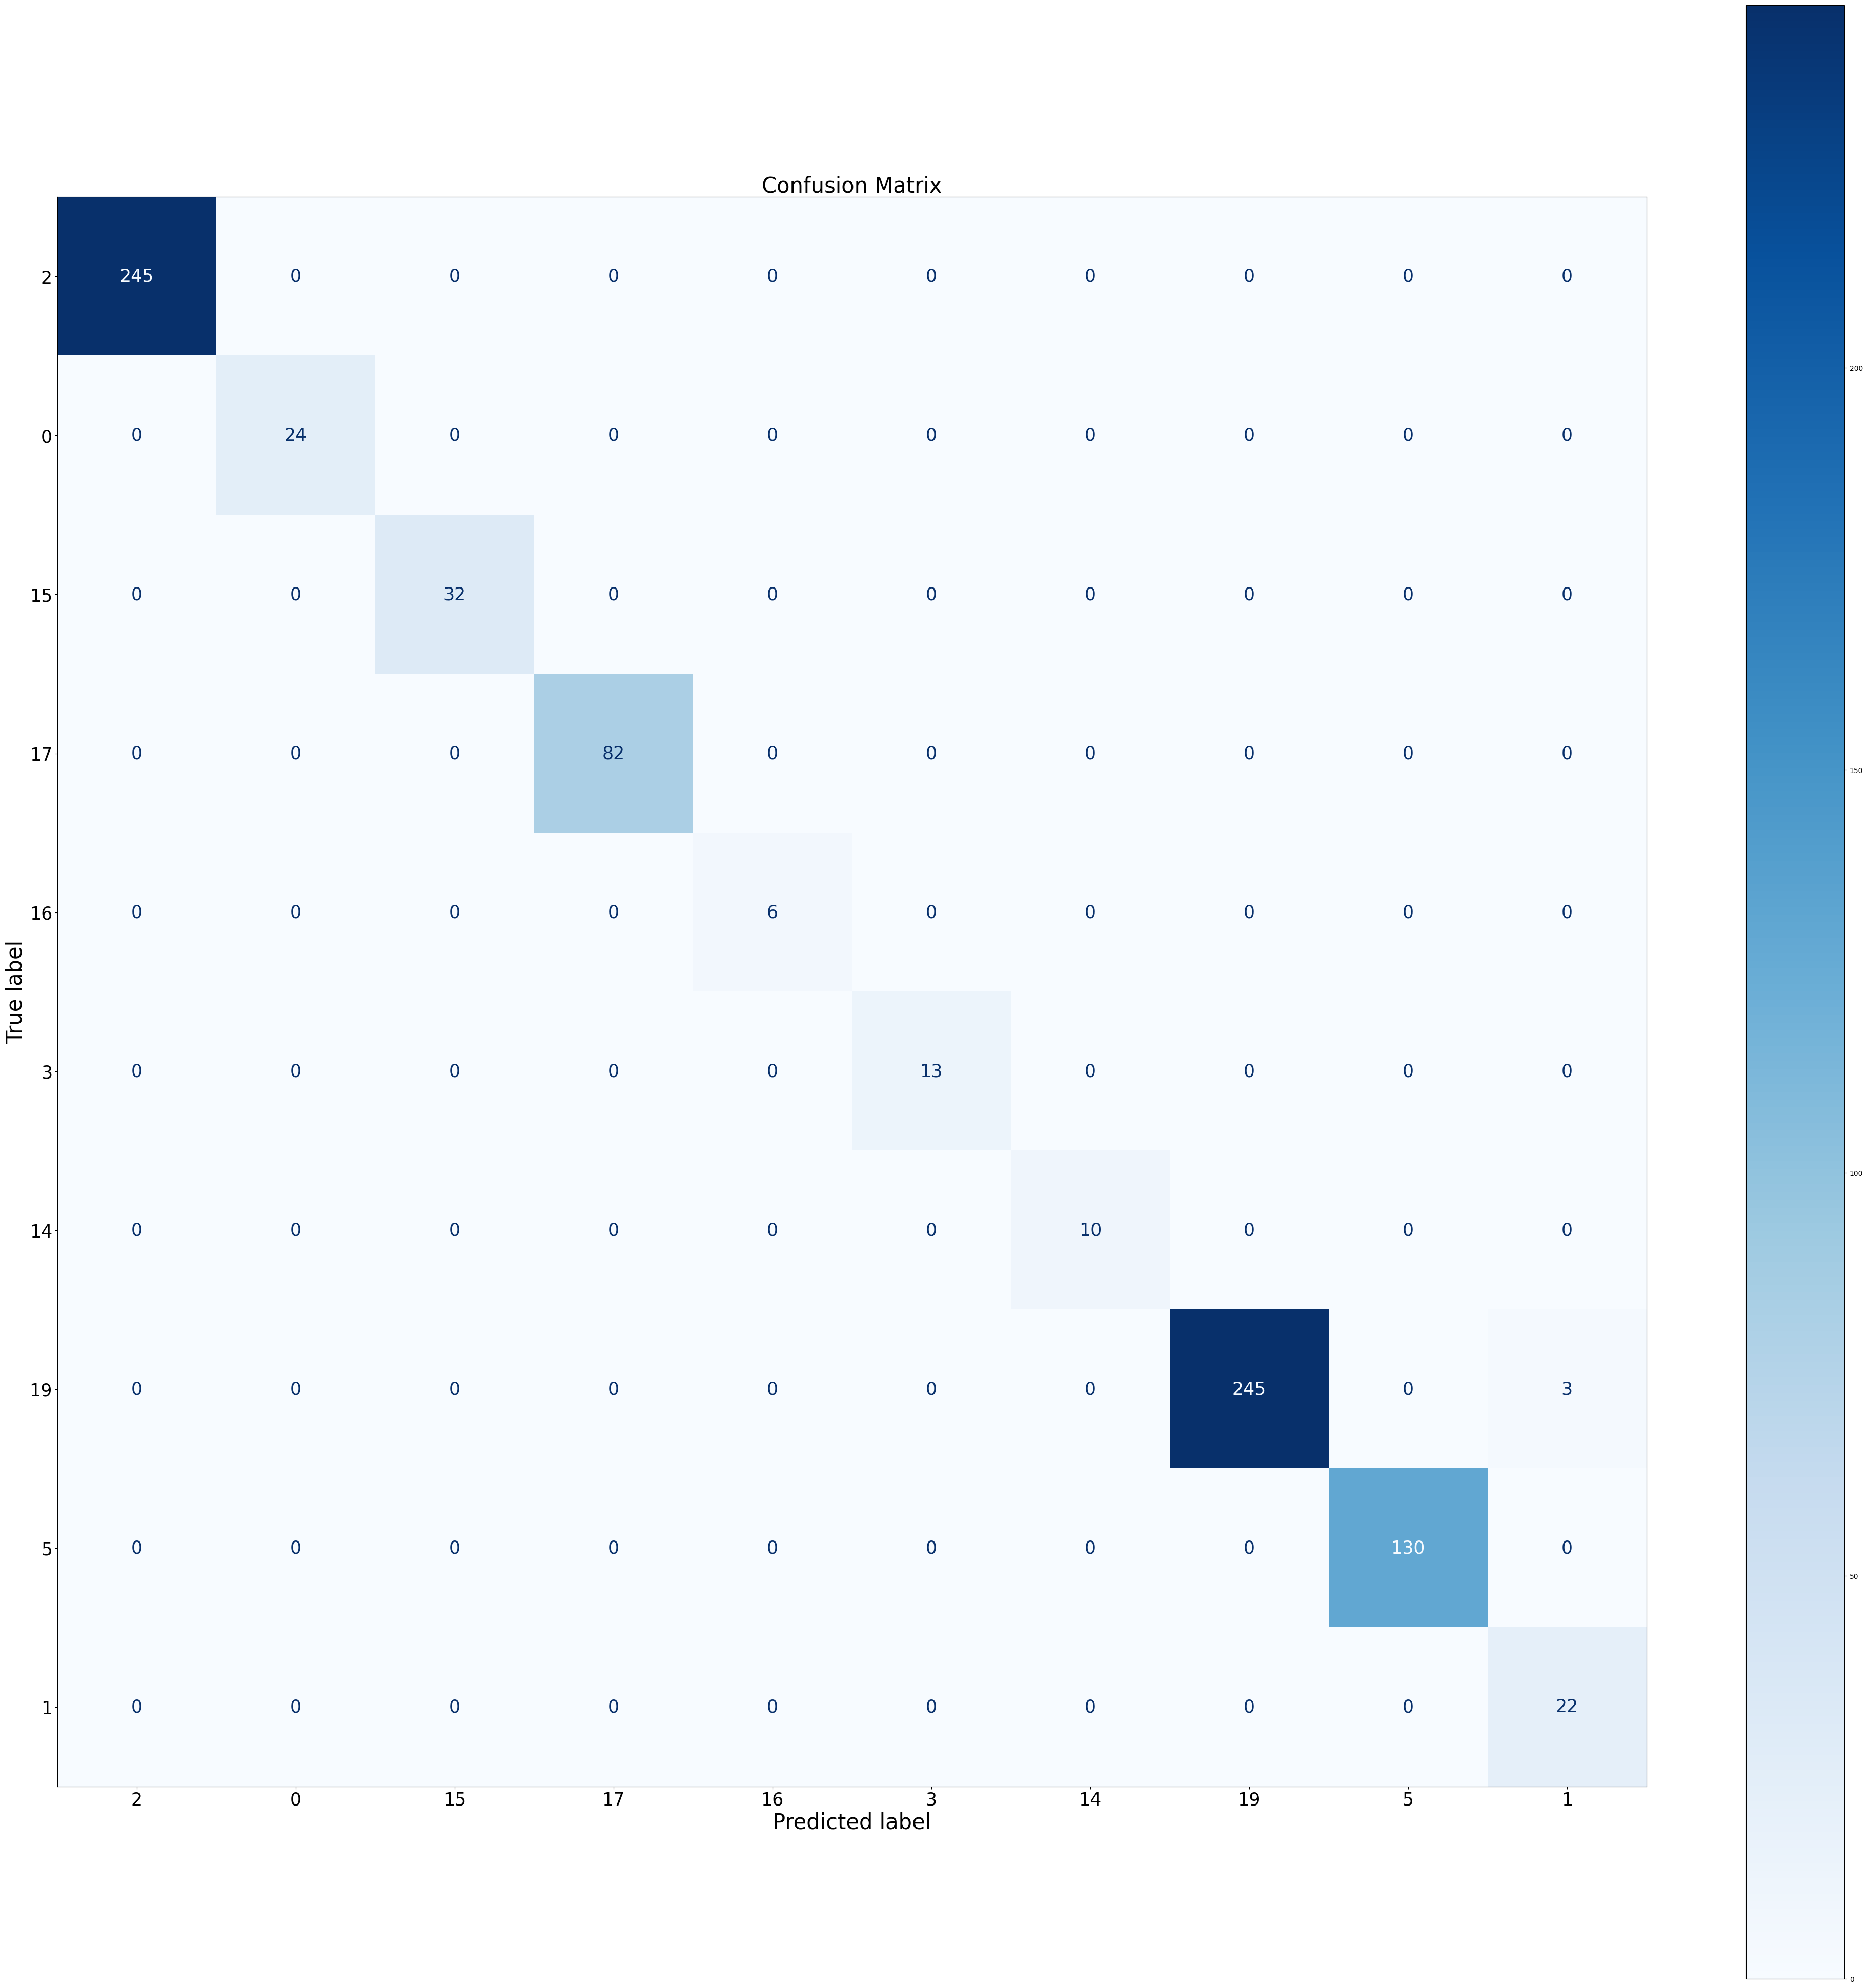

In [86]:
Y_res_train= model.predict(train_gen)
Y_res_train=[REFS_LABELS_MAP[np.argmax(y)] for y in Y_res_train]
y_train_classes=[REFS_LABELS_MAP[y] for y in train_gen.labels]
cm=confusion_matrix(y_train_classes,Y_res_train)
from sklearn.metrics import ConfusionMatrixDisplay
cmd = ConfusionMatrixDisplay(cm,display_labels=REFS_LABELS_MAP.values())
fig, ax = plt.subplots(figsize=(50, 50))  # Adjusted size for better readability
plt.xticks(fontsize=25)  # Set font size for x-axis labels
plt.yticks(fontsize=25)  # Set font size for y-axis labels
plt.xlabel("Predicted Label", fontsize=30)
plt.ylabel("True Label", fontsize=30)
plt.title("Confusion Matrix", fontsize=30)
cmd.plot(cmap='Blues',ax=ax)
for i in range(len(cmd.text_)):
    for j in range(len(cmd.text_[i])):
        cmd.text_[i][j].set_fontsize(25)  # Set the font size for the numbers inside the cells

plt.show()

In [87]:
report= classification_report(y_train_classes,Y_res_train)
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       245
           1       1.00      1.00      1.00        24
          14       1.00      1.00      1.00        32
          15       1.00      1.00      1.00        82
          16       1.00      1.00      1.00         6
          17       1.00      1.00      1.00        13
          19       1.00      1.00      1.00        10
           2       1.00      0.99      0.99       248
           3       1.00      1.00      1.00       130
           5       0.88      1.00      0.94        22

    accuracy                           1.00       812
   macro avg       0.99      1.00      0.99       812
weighted avg       1.00      1.00      1.00       812



## Shuffle test Data = false

In [88]:
test_gen=generator.flow_from_dataframe(
    dataframe=test_df,
    directory='/',
    x_col='path',
    y_col='label',
    class_mode='categorical',
    color_mode='rgb',
    batch_size=16,
    target_size=(128,256),
    shuffle=False
)

Found 204 validated image filenames belonging to 10 classes.


In [89]:
res0_test=model.evaluate(test_gen)
res0_test

 7/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9875 - binary_accuracy: 0.9972 - f1_score: 0.6995 - loss: 0.0050 - precision: 0.9874 - recall: 0.9847

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9829 - binary_accuracy: 0.9962 - f1_score: 0.7798 - loss: 0.0115 - precision: 0.9828 - recall: 0.9786


[0.01730884611606598,
 <tf.Tensor: shape=(10,), dtype=float32, numpy=
 array([1.        , 1.        , 1.        , 1.        , 0.        ,
        0.74999994, 1.        , 0.9838709 , 0.9846153 , 0.92307687],
       dtype=float32)>,
 0.9802955389022827,
 0.9754902124404907,
 0.9803921580314636,
 0.9955882430076599]

### metrics

#### Confusion matrix

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


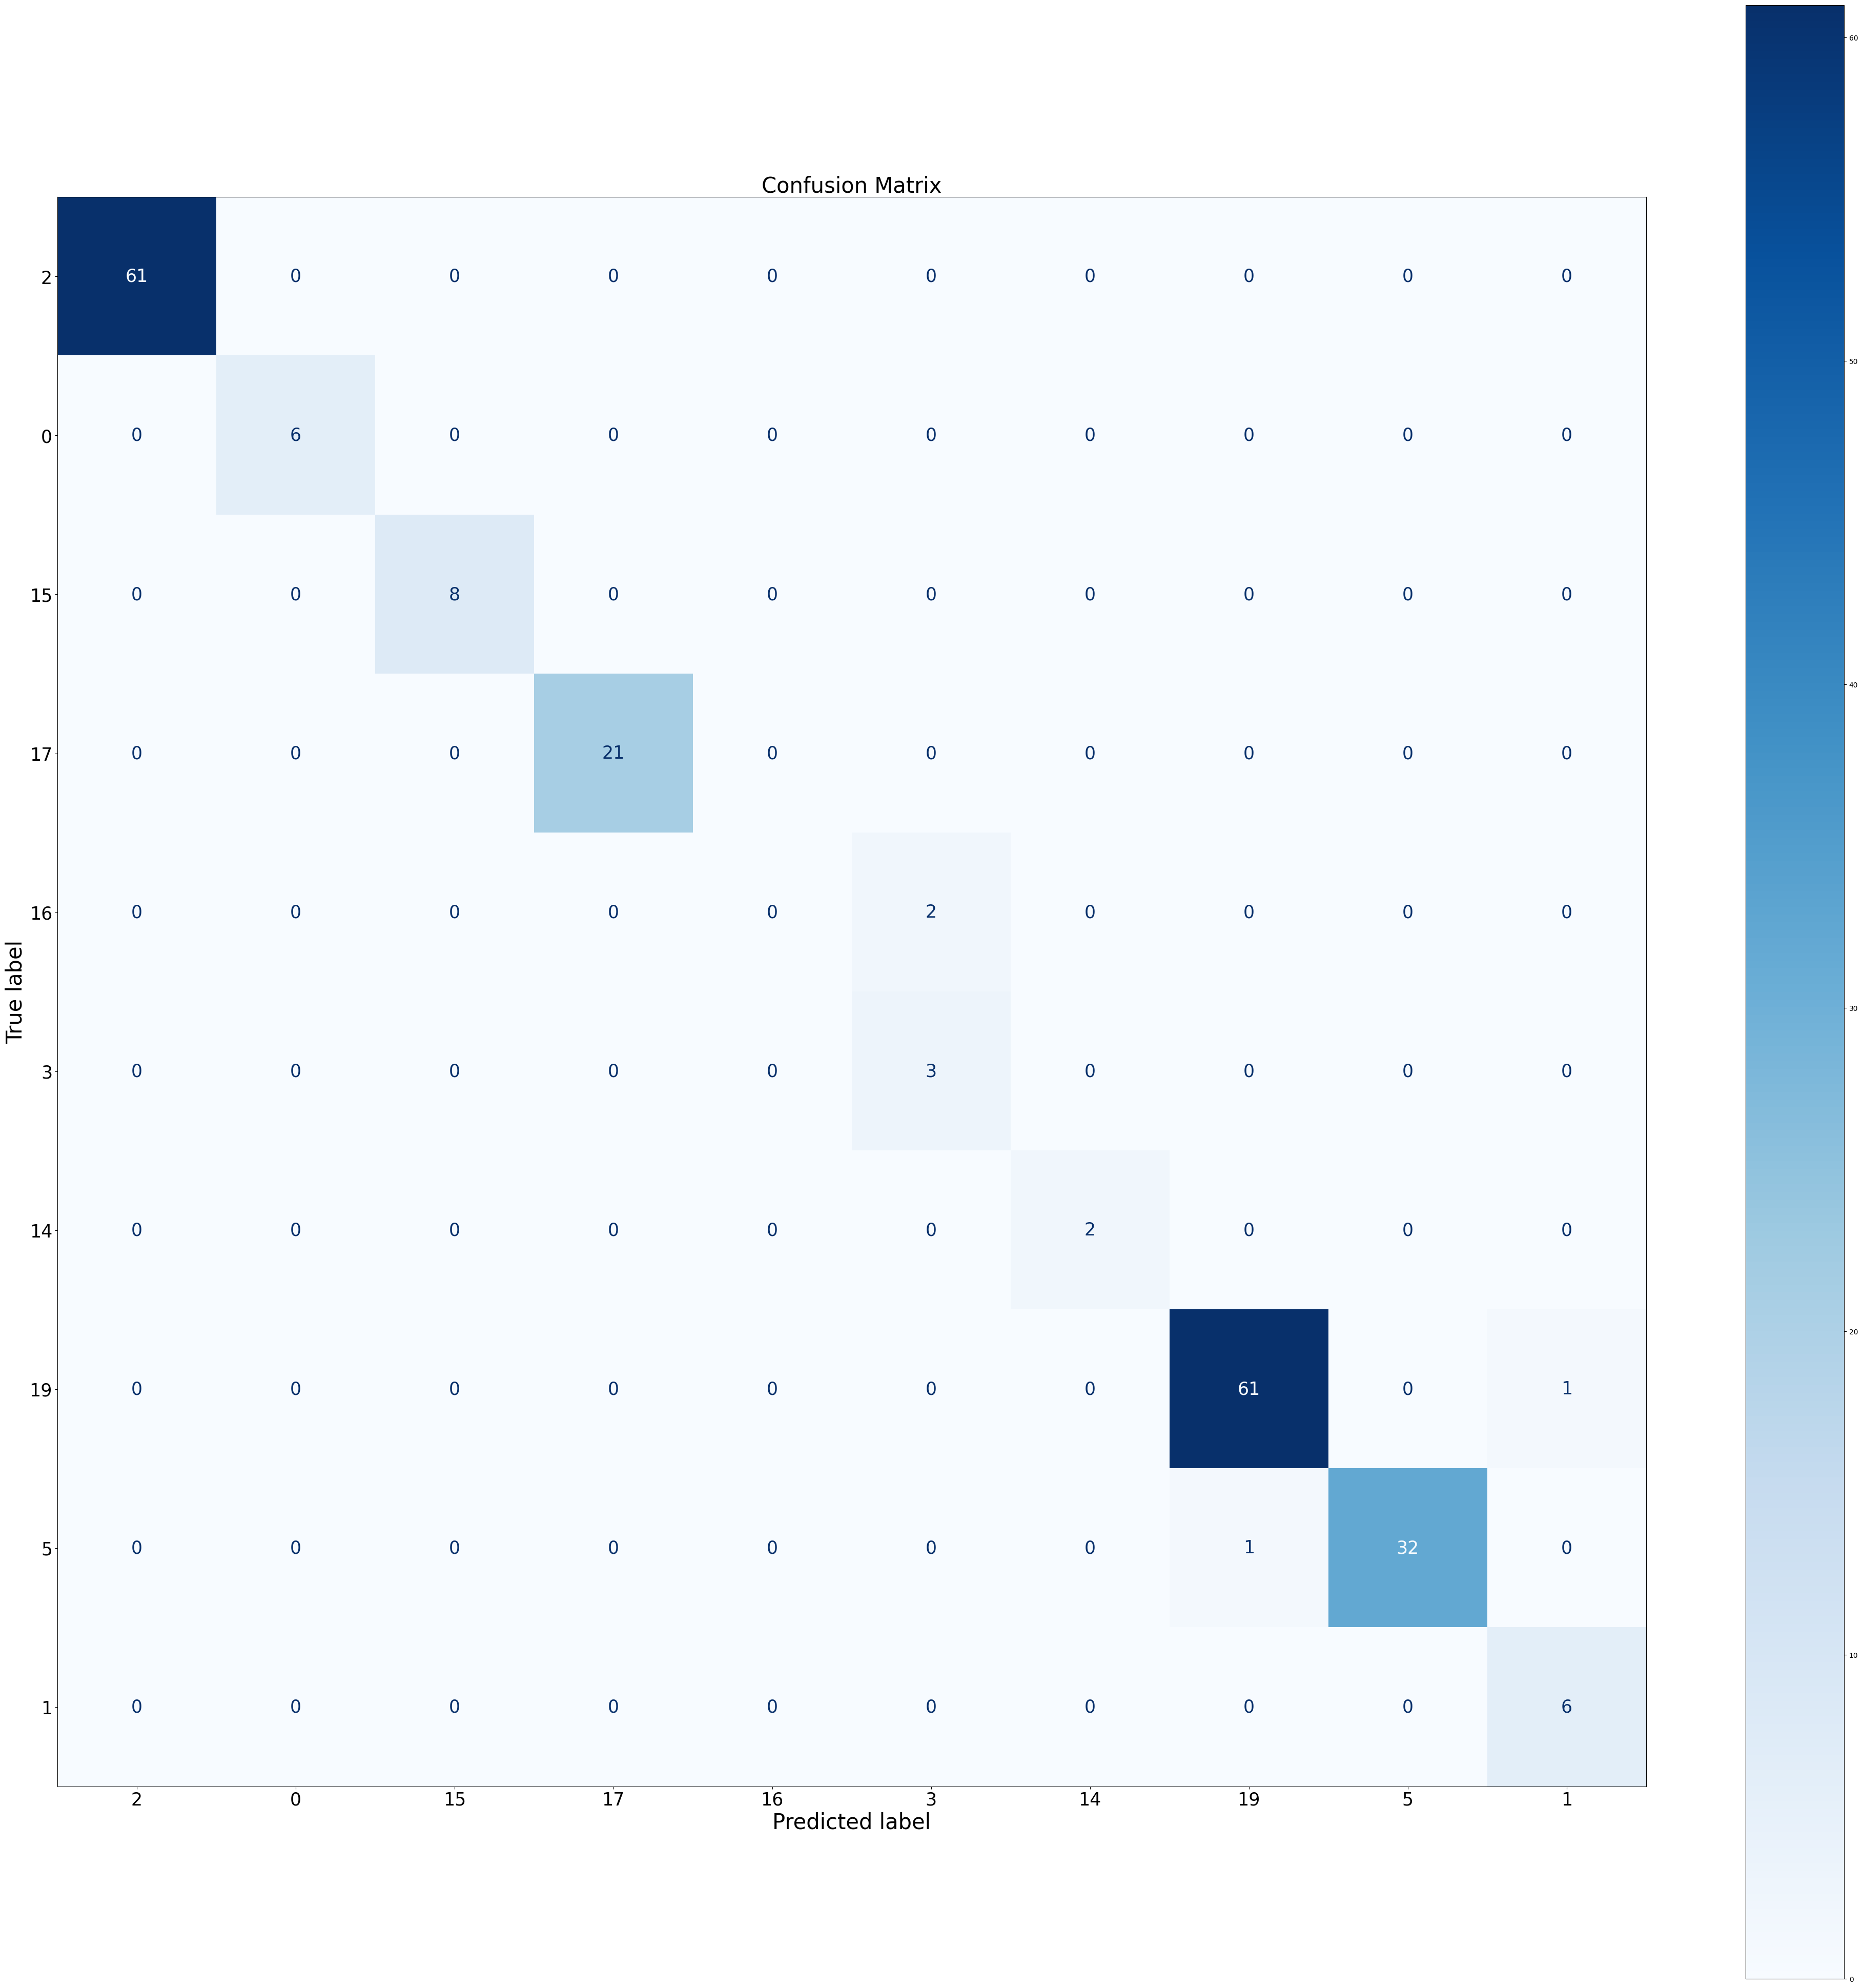

In [90]:
Y_res_test= model.predict(test_gen)
Y_res_test=[REFS_LABELS_MAP[np.argmax(y)] for y in Y_res_test]
y_test_classes=[REFS_LABELS_MAP[y] for y in test_gen.labels]
cm=confusion_matrix(y_test_classes,Y_res_test)
from sklearn.metrics import ConfusionMatrixDisplay
cmd = ConfusionMatrixDisplay(cm,display_labels=REFS_LABELS_MAP.values())
fig, ax = plt.subplots(figsize=(50, 50))  # Adjusted size for better readability
plt.xticks(fontsize=25)  # Set font size for x-axis labels
plt.yticks(fontsize=25)  # Set font size for y-axis labels
plt.xlabel("Predicted Label", fontsize=30)
plt.ylabel("True Label", fontsize=30)
plt.title("Confusion Matrix", fontsize=30)
cmd.plot(cmap='Blues',ax=ax)
for i in range(len(cmd.text_)):
    for j in range(len(cmd.text_[i])):
        cmd.text_[i][j].set_fontsize(25)  # Set the font size for the numbers inside the cells

plt.show()

#### classification report

In [91]:
report= classification_report(y_test_classes,Y_res_test)
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        61
           1       1.00      1.00      1.00         6
          14       1.00      1.00      1.00         8
          15       1.00      1.00      1.00        21
          16       0.00      0.00      0.00         2
          17       0.60      1.00      0.75         3
          19       1.00      1.00      1.00         2
           2       0.98      0.98      0.98        62
           3       1.00      0.97      0.98        33
           5       0.86      1.00      0.92         6

    accuracy                           0.98       204
   macro avg       0.84      0.90      0.86       204
weighted avg       0.98      0.98      0.98       204



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


#### Top 5 accuracy score

In [92]:
y_test_scores= model.predict(test_gen)
top_5_accuracy_score=top_k_accuracy_score(test_gen.labels,y_test_scores,k=5)
print("Top 5 accuracy score: "+str(top_5_accuracy_score))

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Top 5 accuracy score: 1.0


#### Wrong test predictions

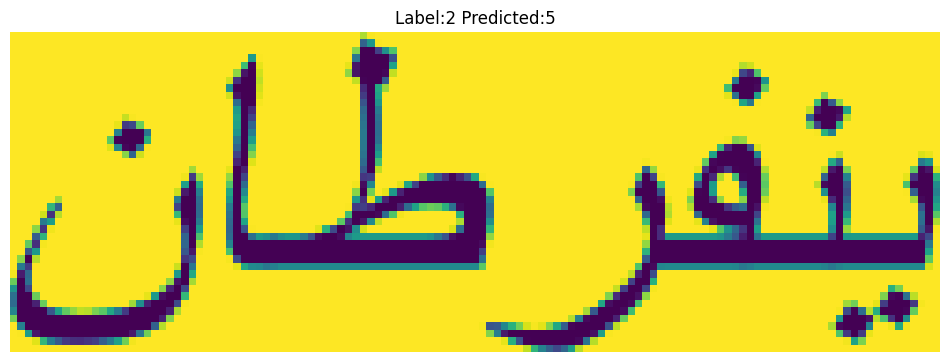

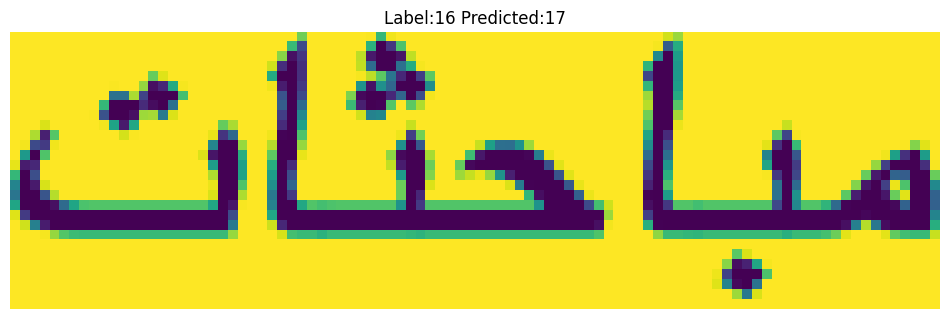

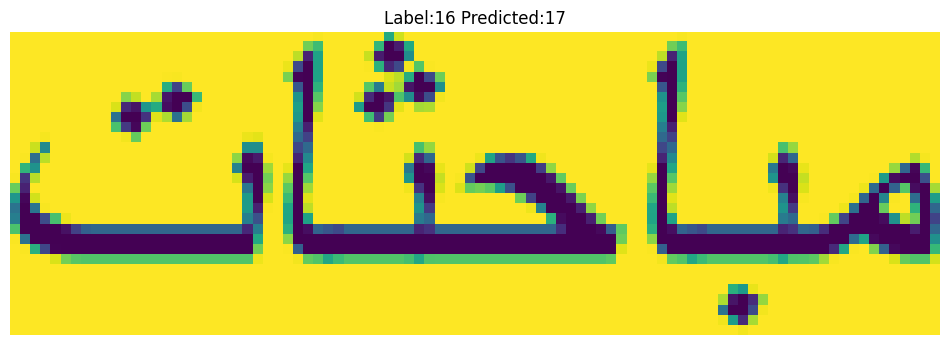

Error at index 138: not a PNG file


In [93]:
for index in range(len(Y_res0_test)):
    try:
        if Y_res_test[index] != y_test_classes[index]:
            img = plt.imread(test_df['path'].values[index])
            plt.figure(figsize=(12, 6))
            plt.title(
                "Label:" + y_test_classes[index] +
                " Predicted:" + Y_res_test[index]
            )
            plt.imshow(img)
            plt.axis("off")
            plt.show()
    except Exception as e:
        print(f"Error at index {index}: {e}")
        continue
